# EDA chuyên sâu dữ liệu VisDrone cho bài toán Object Detection

Notebook này kiểm tra cấu trúc dữ liệu, tính toàn vẹn ảnh/nhãn, phân phối lớp, kích thước ảnh, mật độ đối tượng, hình học bounding box, mức che khuất/cắt cụt, độ lệch giữa các split, trùng lặp/rò rỉ dữ liệu, chất lượng ảnh và trực quan hóa các trường hợp cực trị. Phần cuối chuyển các phát hiện thành quyết định preprocessing và huấn luyện cụ thể.

**Định dạng nhãn gốc:** `x, y, width, height, score, category, truncation, occlusion`. Category `1..10` là 10 lớp huấn luyện; category `0`, `11` và dòng có `score=0` không được đưa vào nhãn YOLO.

**Nguyên tắc:** mọi thống kê về mô hình chỉ sử dụng box có `status == 'keep'`; các box bị bỏ vẫn được thống kê riêng để audit chất lượng nhãn.

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa src/ và data/.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print('Project root:', PROJECT_ROOT)
print('Data root   :', DATA_ROOT)

Project root: /Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Object_dectection
Data root   : /Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Object_dectection/data


In [2]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageDraw

from visdrone_data import CLASS_NAMES, discover_splits, read_annotation_file, scan_dataset

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
RANDOM_SEED = 42
SPLITS = ('train', 'val', 'test-dev')
random.seed(RANDOM_SEED)

## 1. Khám phá cấu trúc và quét dữ liệu

Hàm quét tự xử lý trường hợp archive tạo hai thư mục trùng tên, ví dụ `VisDrone2019-DET-train/VisDrone2019-DET-train`. Không cần di chuyển dữ liệu gốc.

In [3]:
split_paths = discover_splits(DATA_ROOT)
pd.DataFrame([{'split': split_name, 'path': path} for split_name, path in split_paths.items()])

,split,path
0,train,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
1,val,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
2,test-dev,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
3,test-challenge,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...


In [4]:
# Quét toàn bộ metadata ảnh và annotation; có thể mất khoảng 1-2 phút.
images_df, boxes_df, integrity_df = scan_dataset(DATA_ROOT, SPLITS)
print(f'{len(images_df):,} ảnh; {len(boxes_df):,} annotation gốc')
integrity_df

8,629 ảnh; 471,266 annotation gốc


,split,split_path,images,annotations,missing_annotations,missing_images,unreadable_images,malformed_rows
0,train,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...,6471,6471,0,0,0,0
1,val,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...,548,548,0,0,0,0
2,test-dev,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...,1610,1610,0,0,0,0


### Báo cáo tóm tắt và kết luận phần 1

- Đã tìm thấy đủ bốn thư mục `train`, `val`, `test-dev`, `test-challenge`; ba split có nhãn được dùng cho EDA và huấn luyện.
- Tổng dữ liệu có nhãn gồm **8.629 ảnh** và **471.266 annotation gốc**, đúng quy mô công bố: 6.471 train, 548 validation, 1.610 test-dev.
- Cấu trúc thư mục lồng hai lần được hàm `discover_splits` xử lý đúng, nên không cần di chuyển hay đổi tên raw data.

**Kết luận:** dữ liệu đã được phát hiện đầy đủ và có thể tiếp tục kiểm tra chất lượng. `test-challenge` không có ground truth nên chỉ phù hợp inference/submission, không dùng để tính metric nội bộ.

## 2. Tính toàn vẹn dữ liệu

Các cột `missing_*`, `unreadable_images` và `malformed_rows` phải bằng 0 trước khi train. Ảnh test-challenge không có annotation theo thiết kế nên không nằm trong lần quét huấn luyện này.

In [5]:
quality_columns = ['missing_annotations', 'missing_images', 'unreadable_images', 'malformed_rows']
integrity_df[['split', 'images', 'annotations', *quality_columns]]

,split,images,annotations,missing_annotations,missing_images,unreadable_images,malformed_rows
0,train,6471,6471,0,0,0,0
1,val,548,548,0,0,0,0
2,test-dev,1610,1610,0,0,0,0


In [6]:
status_table = (boxes_df.groupby(['split', 'status']).size()
                .unstack(fill_value=0)
                .assign(total=lambda frame: frame.sum(axis=1)))
status_table.loc['TOTAL'] = status_table.sum()
status_table

status,ignored_score,keep,non_positive_boxes,total
split,,,,
test-dev,2445,75102,0,77547
train,10345,343204,1,353550
val,1410,38759,0,40169
TOTAL,14200,457065,1,471266


### Báo cáo tóm tắt và kết luận phần 2

- Không thiếu cặp ảnh–annotation, không có ảnh không đọc được và không có dòng annotation malformed.
- Trong 471.266 dòng: **457.065 box hợp lệ**, **14.200 ignored region** (`score=0`) và **1 box train có kích thước không dương**.
- Tỷ lệ box được giữ là khoảng **96,99%**; ignored region và box lỗi không được chuyển thành nhãn huấn luyện.

**Kết luận:** integrity cơ bản đạt yêu cầu. Pipeline phải tiếp tục loại 14.200 ignored region và box không dương; không được coi ignored region là background âm thông thường.

## 3. Kích thước và tỉ lệ ảnh

YOLO tự letterbox ảnh về `imgsz`; không resize đè lên ảnh gốc. Nên chọn `imgsz` đủ lớn vì VisDrone có nhiều vật thể rất nhỏ.

width                                                          \
           count     mean     std    min     25%     50%     75%     max   
split                                                                      
test-dev  1610.0  1442.48  187.87  960.0  1400.0  1400.0  1400.0  1920.0   
train     6471.0  1519.89  269.52  480.0  1400.0  1400.0  1916.0  2000.0   
val        548.0  1291.09  203.79  960.0  1360.0  1360.0  1360.0  1920.0   

          height                                                 ...  \
           count     mean     std    min    25%     50%     75%  ...   
split                                                            ...   
test-dev  1610.0   856.38  136.89  540.0  788.0   788.0  1050.0  ...   
train     6471.0  1002.40  235.06  360.0  788.0  1050.0  1078.0  ...   
val        548.0   726.24  114.63  540.0  765.0   765.0   765.0  ...   

         aspect_ratio                                     file_size_kb  \
                 mean   std   min   25%   50%   75%   max        count   
split                                                                    
test-dev         1.70  0.17  1.33  1.78  1.78  1.78  1.78       1610.0   
train            1.55  0.22  1.33  1.33  1.33  1.78  1.78       6471.0   
val              1.78  0.00  1.78  1.78  1.78  1.78  1.78        548.0   

                                                                 
            mean     std    min     25%     50%     75%     max  
split                                                            
test-dev  188.65   86.68  43.70  125.93  181.86  215.24  496.87  
train     233.60  125.55  19.94  145.63  202.90  287.41  824.72  
val       144.72   58.50  33.01  103.71  139.38  167.34  468.00  

[3 rows x 32 columns]

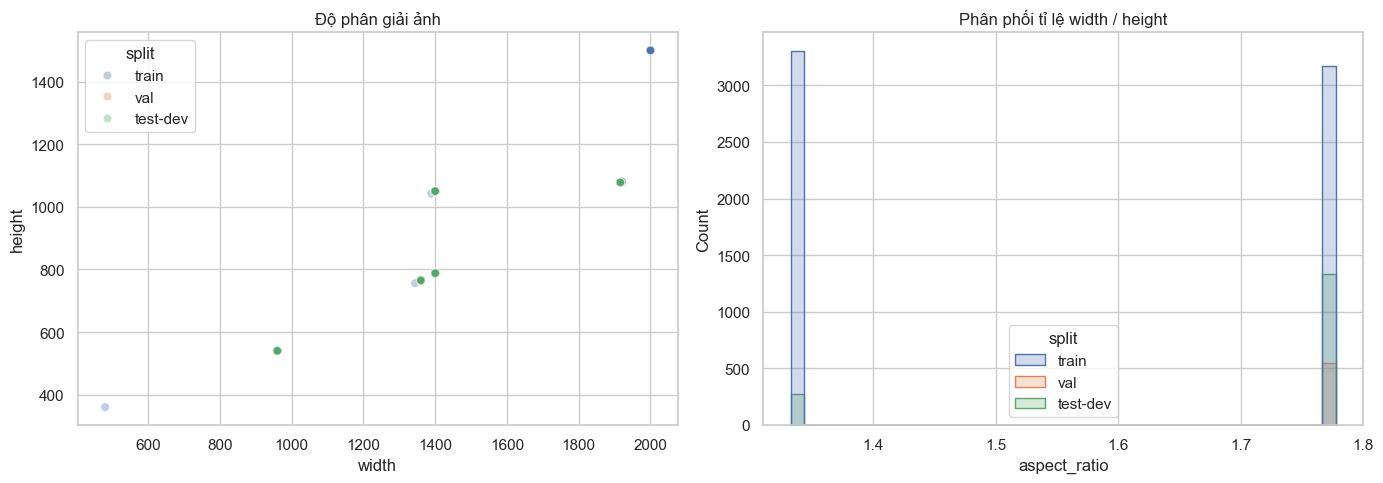

In [7]:
image_stats = images_df.assign(aspect_ratio=images_df.width / images_df.height)
display(image_stats.groupby('split')[['width', 'height', 'aspect_ratio', 'file_size_kb']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=image_stats, x='width', y='height', hue='split', alpha=.35, ax=axes[0])
axes[0].set_title('Độ phân giải ảnh')
sns.histplot(data=image_stats, x='aspect_ratio', hue='split', bins=40, element='step', ax=axes[1])
axes[1].set_title('Phân phối tỉ lệ width / height')
plt.tight_layout();

### Báo cáo tóm tắt và kết luận phần 3

- Ảnh có độ phân giải không đồng nhất; train trải từ 480 đến 2.000 pixel chiều rộng, trong khi validation chủ yếu có aspect ratio **1,78**.
- Width trung vị phổ biến khoảng 1.360–1.400 pixel; train có nhiều ảnh cao và dung lượng lớn hơn validation.
- Sự khác biệt độ phân giải/aspect ratio giữa split có thể tạo distribution shift nếu resize méo ảnh.

**Kết luận:** phải dùng resize giữ aspect ratio kèm letterbox. Không resize cố định width/height độc lập; cần đánh giá nhiều input size vì vật thể nhỏ sẽ mất tín hiệu khi giảm ảnh mạnh.

## 4. Phân phối lớp và mức mất cân bằng

Chỉ phân tích các box có `status == 'keep'`, tức chính xác các box sẽ được ghi sang YOLO.

,category,class_name,objects,percent
3,4,car,187004,40.91
0,1,pedestrian,109187,23.89
9,10,motor,40378,8.83
1,2,people,38560,8.44
4,5,van,32702,7.15
5,6,truck,16284,3.56
2,3,bicycle,13069,2.86
8,9,bus,9117,1.99
6,7,tricycle,6387,1.40
7,8,awning-tricycle,4377,0.96


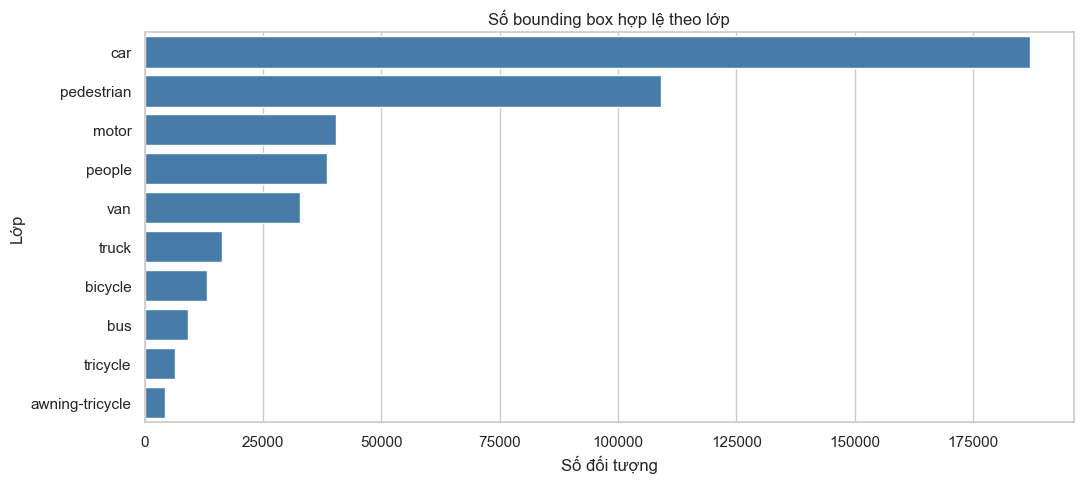

In [8]:
valid_boxes = boxes_df.query("status == 'keep'").copy()
class_counts = (valid_boxes.groupby(['category', 'class_name']).size()
                .rename('objects').reset_index().sort_values('objects', ascending=False))
class_counts['percent'] = 100 * class_counts.objects / class_counts.objects.sum()
display(class_counts.round({'percent': 2}))

plt.figure(figsize=(11, 5))
sns.barplot(data=class_counts, x='objects', y='class_name', color='#377eb8')
plt.title('Số bounding box hợp lệ theo lớp')
plt.xlabel('Số đối tượng'); plt.ylabel('Lớp'); plt.tight_layout();

### Báo cáo tóm tắt và kết luận phần 4

- `car` chiếm **40,91%**, `pedestrian` **23,89%**; hai lớp này chiếm gần 65% toàn bộ box.
- `awning-tricycle` chỉ **0,96%**, `tricycle` **1,40%**, `bus` **1,99%**.
- Chênh lệch lớp lớn nhất/xấp xỉ nhỏ nhất khoảng **44,6 lần** trên train.

**Kết luận:** mAP tổng có thể che giấu chất lượng kém của lớp hiếm. Cần báo cáo AP từng lớp, confusion matrix và thử targeted copy-paste/focal-style loss thay vì chỉ nhìn accuracy tổng.

## 5. Hình học bounding box và vật thể nhỏ

`relative_area` là diện tích box / diện tích ảnh. Các ngưỡng dưới đây chỉ dùng để EDA; pipeline mặc định không xóa vật thể nhỏ hợp lệ vì đó là tín hiệu quan trọng của VisDrone.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
clipped_width,457065.0,36.6511,38.9668,2.0000,3.0000,5.0000,12.0000,24.0000,46.0000,110.0000,189.0000,983.0000
clipped_height,457065.0,36.0649,32.7265,1.0000,5.0000,8.0000,16.0000,26.0000,44.0000,97.0000,166.0000,790.0000
area_px,457065.0,2243.8620,6189.2745,3.0000,21.0000,50.0000,221.0000,627.0000,1850.0000,9102.0000,25812.1200,355432.0000
relative_area,457065.0,0.0015,0.0039,0.0000,0.0000,0.0000,0.0002,0.0005,0.0013,0.0061,0.0163,0.3416
aspect_ratio,457065.0,1.0737,0.6651,0.0536,0.2778,0.3529,0.5500,0.8855,1.4286,2.3889,2.9545,12.5417


,value
box < 16x16 px (%),38.91
box < 32x32 px (%),72.13
area < 0.1% ảnh (%),69.19
box bị clip (%),0.00


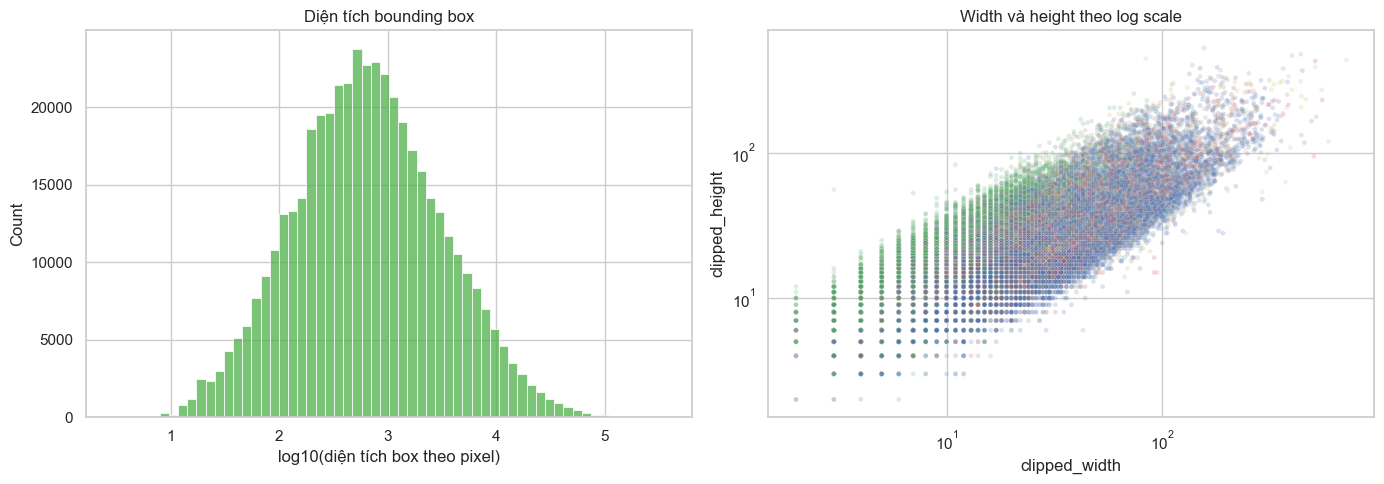

In [9]:
geometry_summary = valid_boxes[['clipped_width', 'clipped_height', 'area_px', 'relative_area', 'aspect_ratio']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).T
display(geometry_summary.round(4))

small_object_summary = pd.Series({
    'box < 16x16 px (%)': 100 * ((valid_boxes.clipped_width < 16) | (valid_boxes.clipped_height < 16)).mean(),
    'box < 32x32 px (%)': 100 * ((valid_boxes.clipped_width < 32) | (valid_boxes.clipped_height < 32)).mean(),
    'area < 0.1% ảnh (%)': 100 * (valid_boxes.relative_area < .001).mean(),
    'box bị clip (%)': 100 * valid_boxes.was_clipped.mean(),
}).round(2)
display(small_object_summary.to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.log10(valid_boxes.area_px.clip(lower=1)), bins=60, ax=axes[0], color='#4daf4a')
axes[0].set(xlabel='log10(diện tích box theo pixel)', title='Diện tích bounding box')
sample = valid_boxes.sample(min(30000, len(valid_boxes)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample, x='clipped_width', y='clipped_height', hue='class_name', alpha=.2, s=12, legend=False, ax=axes[1])
axes[1].set(xscale='log', yscale='log', title='Width và height theo log scale')
plt.tight_layout();

### Báo cáo tóm tắt và kết luận phần 5

- Median box chỉ khoảng **24×26 pixel** trên ảnh gốc; **38,91%** box có ít nhất một cạnh dưới 16 pixel và **72,13%** dưới 32 pixel.
- **69,19%** box chiếm dưới 0,1% diện tích ảnh; median relative area chỉ khoảng 0,05%.
- Không có box hợp lệ phải clip biên sau quy tắc lọc hiện tại.

**Kết luận:** đây rõ ràng là bài toán small/tiny-object detection. High-resolution input, feature map stride nhỏ, anchor nhỏ và tiled inference là các hướng cần ưu tiên; random crop/downscale mạnh có nguy cơ làm mất nhãn.

## 6. Mật độ, truncation và occlusion

Ảnh có rất nhiều đối tượng và nhiều box bị che khuất. Không nên loại các box occlusion/truncation cao một cách mặc định; có thể dùng chúng để phân tích lỗi sau huấn luyện.

raw_objects                                               \
               count   mean    std  min   25%   50%    75%    max   
split                                                               
test-dev      1610.0  48.17  46.86  1.0  21.0  37.0  58.00  498.0   
train         6471.0  54.64  45.22  1.0  24.0  43.0  72.00  914.0   
val            548.0  73.30  47.62  1.0  42.0  68.0  96.25  341.0   

         trainable_objects                                               
                     count   mean    std  min    25%   50%   75%    max  
split                                                                    
test-dev            1610.0  46.65  44.06  1.0  20.00  36.0  57.0  461.0  
train               6471.0  53.04  43.84  1.0  24.00  42.0  70.0  902.0  
val                  548.0  70.73  46.00  1.0  39.75  65.0  93.0  317.0

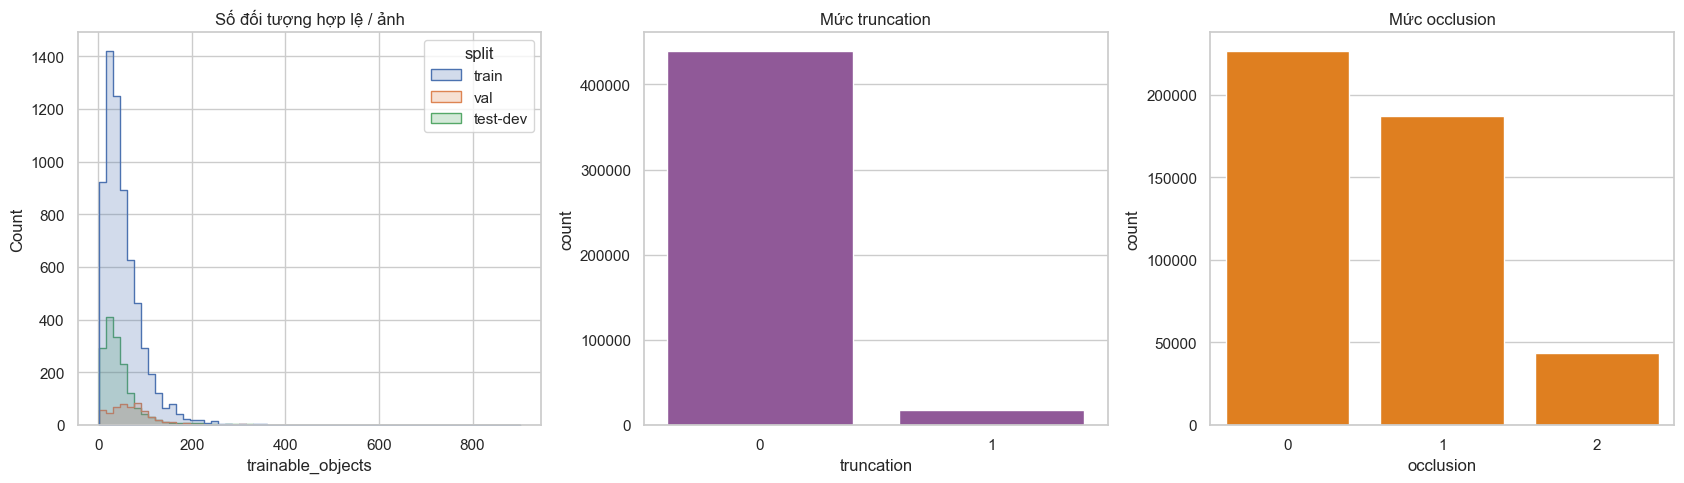

In [10]:
display(images_df.groupby('split')[['raw_objects', 'trainable_objects']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(data=images_df, x='trainable_objects', hue='split', bins=60, element='step', ax=axes[0])
axes[0].set_title('Số đối tượng hợp lệ / ảnh')
sns.countplot(data=valid_boxes, x='truncation', color='#984ea3', ax=axes[1])
axes[1].set_title('Mức truncation')
sns.countplot(data=valid_boxes, x='occlusion', color='#ff7f00', ax=axes[2])
axes[2].set_title('Mức occlusion')
plt.tight_layout();

### Báo cáo tóm tắt và kết luận phần 6

- Train trung bình **53,04 object/ảnh**, validation **70,73**, test-dev **46,65**; ảnh đông nhất có **902 object**.
- Trong các box hợp lệ, khoảng 49,5% không che khuất, 40,9% che khuất một phần và 9,6% che khuất nặng; khoảng 4,0% bị truncation.
- Validation có mật độ cao hơn train, vì vậy recall trên ảnh đông là một chỉ số quan trọng.

**Kết luận:** không loại occlusion/truncation khỏi train. Cần tăng giới hạn proposal/detection/query và báo cáo metric riêng theo mật độ, occlusion và truncation.

## 7. Trực quan hóa ảnh và nhãn gốc

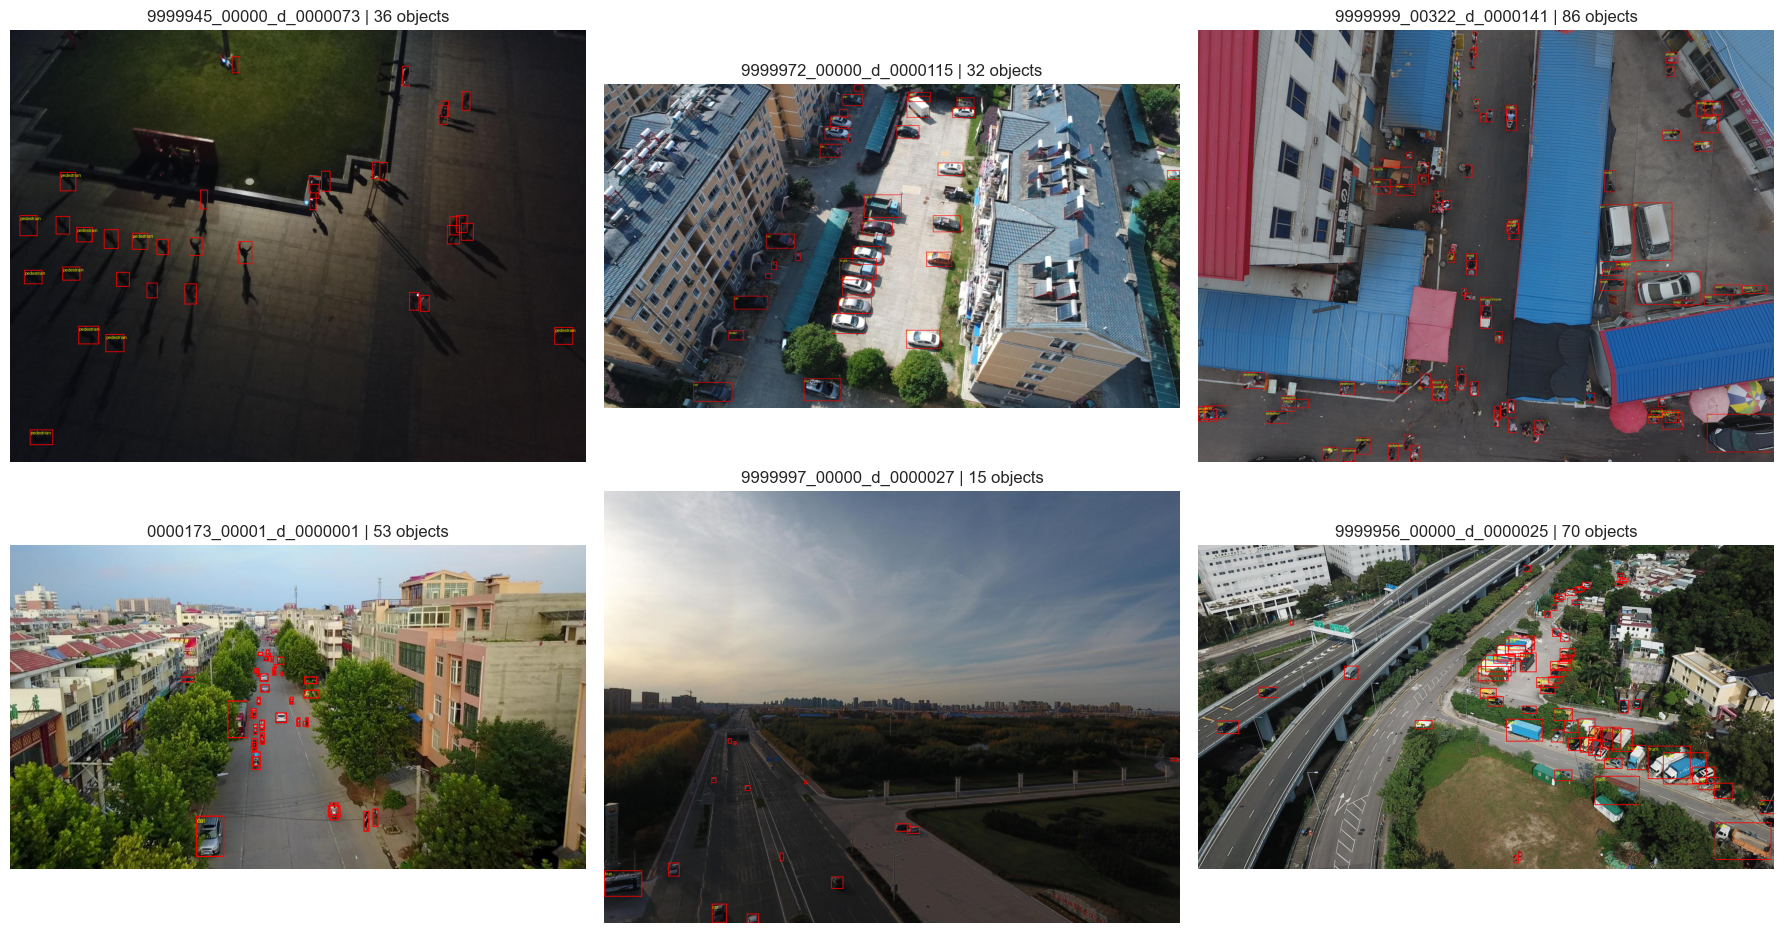

In [11]:
def draw_visdrone_sample(row, line_width=2):
    image = Image.open(row.image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    annotation_path = Path(row.annotation_path)
    annotations, _ = read_annotation_file(annotation_path)
    for ann in annotations:
        if ann.score <= 0 or ann.category not in CLASS_NAMES:
            continue
        x1, y1 = max(0, ann.x), max(0, ann.y)
        x2, y2 = min(image.width, ann.x + ann.width), min(image.height, ann.y + ann.height)
        if x2 <= x1 or y2 <= y1:
            continue
        draw.rectangle((x1, y1, x2, y2), outline='red', width=line_width)
        if ann.width > 35 and ann.height > 20:
            draw.text((x1 + 2, y1 + 2), CLASS_NAMES[ann.category], fill='yellow')
    return image

sample_rows = images_df.query("split == 'train' and trainable_objects > 0").sample(6, random_state=RANDOM_SEED)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    ax.imshow(draw_visdrone_sample(row))
    ax.set_title(f'{row.image_id} | {row.trainable_objects} objects')
    ax.axis('off')
plt.tight_layout();

### Báo cáo tóm tắt và kết luận phần 7

- Các mẫu ngẫu nhiên xác nhận box rất nhỏ, dày đặc và có nhiều lớp đồng thời trong cùng cảnh giao thông.
- Việc chỉ hiển thị tên lớp cho box đủ lớn giúp hình không bị che kín nhưng mọi box hợp lệ vẫn được vẽ.
- Không quan sát thấy sai lệch tọa độ có hệ thống trong các mẫu trực quan.

**Kết luận:** phép đọc annotation và chuyển tọa độ đang đúng về mặt trực quan. Trước mỗi lần thay đổi augmentation/converter vẫn phải duy trì bước visual sanity check trên ảnh thưa, đông và lớp hiếm.

## 8. Bảng điều khiển tổng quan và các kiểm tra bắt buộc

Cell này gom các chỉ số quan trọng nhất và chủ động dừng nếu dữ liệu thiếu cặp ảnh–nhãn, ảnh không đọc được hoặc annotation bị lỗi cú pháp. `test-challenge` không có nhãn theo thiết kế nên không nằm trong các assertion huấn luyện.

In [12]:
overview = integrity_df.set_index('split')[['images', 'annotations', 'missing_annotations',
                                            'missing_images', 'unreadable_images', 'malformed_rows']].copy()
overview['raw_boxes'] = boxes_df.groupby('split').size()
overview['trainable_boxes'] = valid_boxes.groupby('split').size()
overview['ignored_boxes'] = overview.raw_boxes - overview.trainable_boxes
overview['objects_per_image'] = overview.trainable_boxes / overview.images
overview['ignored_pct'] = 100 * overview.ignored_boxes / overview.raw_boxes
display(overview.round(2))

assert overview[['missing_annotations', 'missing_images', 'unreadable_images', 'malformed_rows']].to_numpy().sum() == 0
assert len(valid_boxes) > 0 and np.isfinite(valid_boxes[['relative_area', 'aspect_ratio']]).all().all()

dashboard = pd.Series({
    'Tổng ảnh có nhãn': len(images_df),
    'Tổng annotation gốc': len(boxes_df),
    'Box dùng để train': len(valid_boxes),
    'Tỷ lệ box được giữ (%)': 100 * len(valid_boxes) / len(boxes_df),
    'Ảnh không có box trainable': int((images_df.trainable_objects == 0).sum()),
    'Số lớp': valid_boxes.class_name.nunique(),
    'Median đối tượng / ảnh': images_df.trainable_objects.median(),
    'Max đối tượng / ảnh': images_df.trainable_objects.max(),
})
display(dashboard.to_frame('value').round(2))

,images,annotations,missing_annotations,missing_images,unreadable_images,malformed_rows,raw_boxes,trainable_boxes,ignored_boxes,objects_per_image,ignored_pct
split,,,,,,,,,,,
train,6471,6471,0,0,0,0,353550,343204,10346,53.04,2.93
val,548,548,0,0,0,0,40169,38759,1410,70.73,3.51
test-dev,1610,1610,0,0,0,0,77547,75102,2445,46.65,3.15


,value
Tổng ảnh có nhãn,8629.00
Tổng annotation gốc,471266.00
Box dùng để train,457065.00
Tỷ lệ box được giữ (%),96.99
Ảnh không có box trainable,0.00
Số lớp,10.00
Median đối tượng / ảnh,42.00
Max đối tượng / ảnh,902.00


### Báo cáo tóm tắt và kết luận phần 8

- Dataset có **8.629 ảnh**, **471.266 annotation gốc**, **457.065 box trainable**, 10 lớp và không có ảnh rỗng sau lọc.
- Median là **42 object/ảnh**, cực đại 902; tỷ lệ ignored theo split nằm trong khoảng 2,93–3,51%.
- Các assertion về file thiếu, ảnh hỏng và annotation malformed đều pass.

**Kết luận:** dataset đủ điều kiện chuyển sang YOLO/COCO và xây dataloader. Các cảnh cực đông vẫn cần cấu hình riêng cho giới hạn output của detector.

## 9. Phân phối lớp theo split và độ phủ ở cấp ảnh

Số box cho biết lượng tín hiệu, còn `image prevalence` cho biết bao nhiêu ảnh thực sự chứa từng lớp. Một lớp có nhiều box nhưng chỉ tập trung trong ít ảnh vẫn có nguy cơ tổng quát hóa kém. Heatmap theo phần trăm giúp phát hiện validation/test không đại diện cho train.

boxes                   box_%              
split           test-dev   train    val test-dev  train    val
class_name                                                    
pedestrian         21006   79337   8844    27.97  23.12  22.82
people              6376   27059   5125     8.49   7.88  13.22
bicycle             1302   10480   1287     1.73   3.05   3.32
car                28074  144866  14064    37.38  42.21  36.29
van                 5771   24956   1975     7.68   7.27   5.10
truck               2659   12875    750     3.54   3.75   1.94
tricycle             530    4812   1045     0.71   1.40   2.70
awning-tricycle      599    3246    532     0.80   0.95   1.37
bus                 2940    5926    251     3.91   1.73   0.65
motor               5845   29647   4886     7.78   8.64  12.61

split,test-dev,train,val
class_name,,,
pedestrian,74.350000,82.920000,94.890000
people,49.500000,61.000000,87.960000
bicycle,23.420000,42.570000,66.420000
car,95.030000,94.780000,93.980000
van,72.550000,76.460000,76.820000
truck,46.580000,54.880000,48.540000
tricycle,15.220000,26.090000,61.500000
awning-tricycle,14.470000,17.790000,40.150000
bus,52.050000,31.260000,23.910000


Imbalance ratio train (max/min): 44.6x


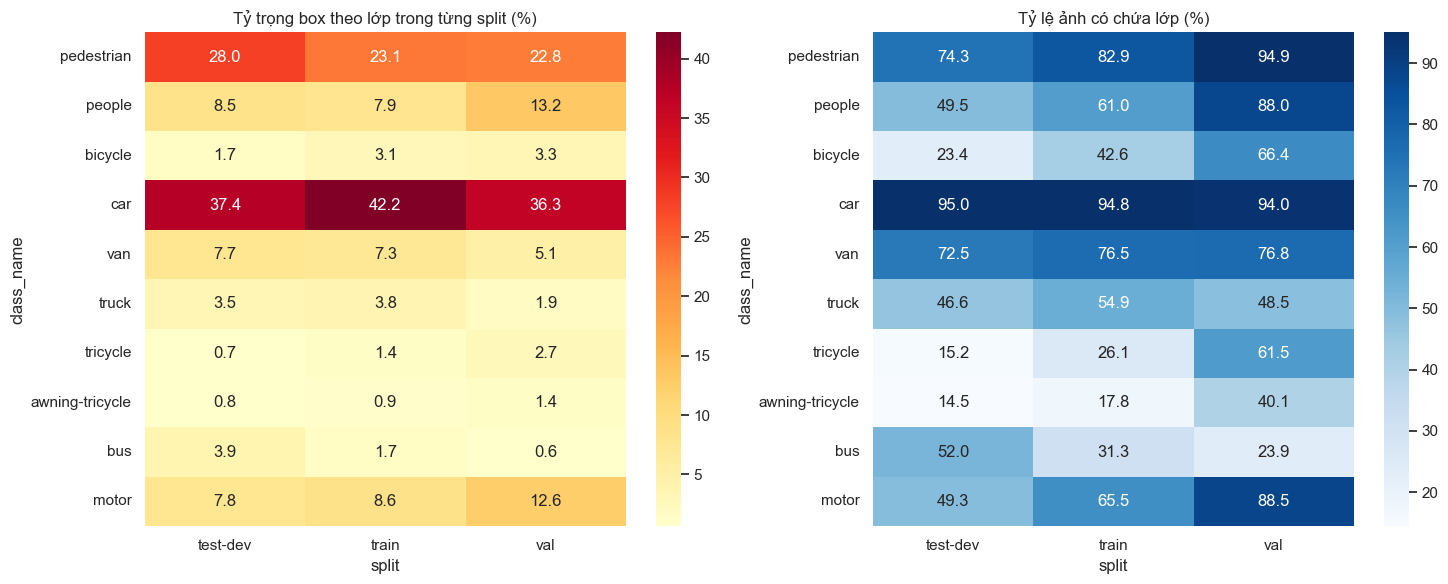

In [13]:
class_by_split = pd.crosstab(valid_boxes.class_name, valid_boxes.split).reindex(CLASS_NAMES.values())
class_pct_by_split = 100 * class_by_split.div(class_by_split.sum(axis=0), axis=1)

image_presence = valid_boxes[['split', 'image_id', 'class_name']].drop_duplicates()
presence_counts = pd.crosstab(image_presence.class_name, image_presence.split).reindex(CLASS_NAMES.values())
split_image_counts = images_df.groupby('split').size()
presence_pct = 100 * presence_counts.div(split_image_counts, axis=1)

display(pd.concat({'boxes': class_by_split, 'box_%': class_pct_by_split.round(2)}, axis=1))
display(presence_pct.round(2).rename_axis('class_name').style.background_gradient(cmap='Blues'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(class_pct_by_split, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Tỷ trọng box theo lớp trong từng split (%)')
sns.heatmap(presence_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Tỷ lệ ảnh có chứa lớp (%)')
plt.tight_layout()

train_counts = class_by_split['train'].sort_values(ascending=False)
print(f'Imbalance ratio train (max/min): {train_counts.max() / train_counts.min():.1f}x')

### Báo cáo tóm tắt và kết luận phần 9

- Phân phối lớp không giống nhau hoàn toàn giữa các split: validation tăng `people` và `motor`, giảm `car`, `truck`, `bus`; test-dev tăng `pedestrian` và `bus`.
- Mất cân bằng không chỉ nằm ở số box mà còn ở mức độ xuất hiện của lớp trong ảnh.
- Train có imbalance ratio khoảng **44,6×** theo số instance.

**Kết luận:** giữ official split để so sánh benchmark nhưng phải báo cáo AP theo lớp. Không cân bằng lại validation/test; chỉ làm train đa dạng hơn và dùng stratified diagnostics để giải thích metric.

## 10. Độ lệch phân phối giữa train, validation và test-dev

Jensen–Shannon divergence bằng 0 khi hai phân phối lớp giống nhau; càng lớn càng khác. KS distance dưới đây đo khác biệt lớn nhất giữa hai phân phối số đối tượng/ảnh. Đây là chẩn đoán độ đại diện của split, không phải tiêu chuẩn pass/fail tuyệt đối.

,class_JS_divergence,object_density_KS,mean_objects_left,mean_objects_right
pair,,,,
train vs val,0.0164,0.2530,53.0372,70.7281
train vs test-dev,0.0084,0.0985,53.0372,46.6472
val vs test-dev,0.0297,0.3470,70.7281,46.6472


split,test-dev - train (pp),train - train (pp),val - train (pp)
class_name,,,
pedestrian,4.85,0.0,-0.30
people,0.61,0.0,5.34
bicycle,-1.32,0.0,0.27
car,-4.83,0.0,-5.92
van,0.41,0.0,-2.18
truck,-0.21,0.0,-1.82
tricycle,-0.70,0.0,1.29
awning-tricycle,-0.15,0.0,0.43
bus,2.19,0.0,-1.08


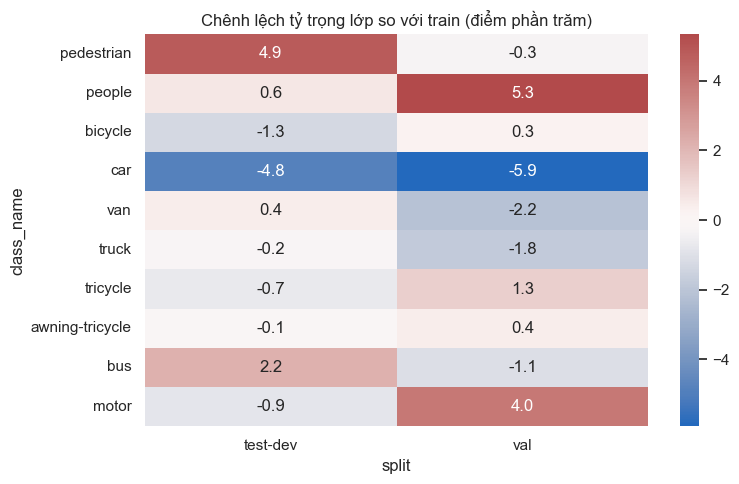

In [14]:
from itertools import combinations

def js_divergence(p, q):
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    p /= p.sum(); q /= q.sum(); m = (p + q) / 2
    left = np.sum(np.where(p > 0, p * np.log2(p / m), 0))
    right = np.sum(np.where(q > 0, q * np.log2(q / m), 0))
    return float((left + right) / 2)

def ks_distance(a, b):
    a = np.sort(np.asarray(a)); b = np.sort(np.asarray(b))
    points = np.sort(np.unique(np.concatenate([a, b])))
    return float(np.max(np.abs(np.searchsorted(a, points, side='right') / len(a)
                               - np.searchsorted(b, points, side='right') / len(b))))

drift_rows = []
for left, right in combinations(SPLITS, 2):
    left_density = images_df.loc[images_df.split == left, 'trainable_objects']
    right_density = images_df.loc[images_df.split == right, 'trainable_objects']
    drift_rows.append({
        'pair': f'{left} vs {right}',
        'class_JS_divergence': js_divergence(class_by_split[left], class_by_split[right]),
        'object_density_KS': ks_distance(left_density, right_density),
        'mean_objects_left': left_density.mean(),
        'mean_objects_right': right_density.mean(),
    })
drift_df = pd.DataFrame(drift_rows).set_index('pair')
display(drift_df.round(4))

delta_vs_train = class_pct_by_split.subtract(class_pct_by_split['train'], axis=0)
display(delta_vs_train.round(2).rename(columns=lambda c: f'{c} - train (pp)'))

plt.figure(figsize=(8, 5))
sns.heatmap(delta_vs_train.drop(columns='train'), annot=True, fmt='.1f', center=0, cmap='vlag')
plt.title('Chênh lệch tỷ trọng lớp so với train (điểm phần trăm)')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 10

- Class JS divergence khá nhỏ nhưng không bằng 0: train–val **0,0164**, train–test **0,0084**.
- Object-density KS lớn hơn rõ rệt: train–val **0,253**, val–test **0,347**.
- So với train, validation giảm `car` 5,92 điểm %, tăng `people` 5,34 và `motor` 3,97 điểm %.

**Kết luận:** shift lớn nhất nằm ở mật độ và tỷ trọng một số lớp, không phải lỗi integrity. Cần theo dõi generalization trên val/test và cân nhắc thêm sequence-aware split như thí nghiệm phụ.

## 11. Vị trí không gian và thiên lệch biên ảnh

Tâm box được chuẩn hóa về `[0, 1]`. Heatmap cho biết mô hình sẽ thấy vật thể ở đâu thường xuyên nhất; thiên lệch mạnh về trung tâm hoặc đáy ảnh có thể làm giảm khả năng tổng quát hóa sang góc camera khác. Box chạm biên cũng thường khó học hơn.

,boxes,median_x,median_y,border_pct
class_name,,,,
pedestrian,109187,0.491,0.405,1.573
people,38560,0.499,0.431,0.978
bicycle,13069,0.497,0.465,1.737
car,187004,0.490,0.350,4.080
van,32702,0.492,0.343,4.367
truck,16284,0.491,0.347,5.994
tricycle,6387,0.504,0.417,2.662
awning-tricycle,4377,0.489,0.398,2.696
bus,9117,0.488,0.344,7.009


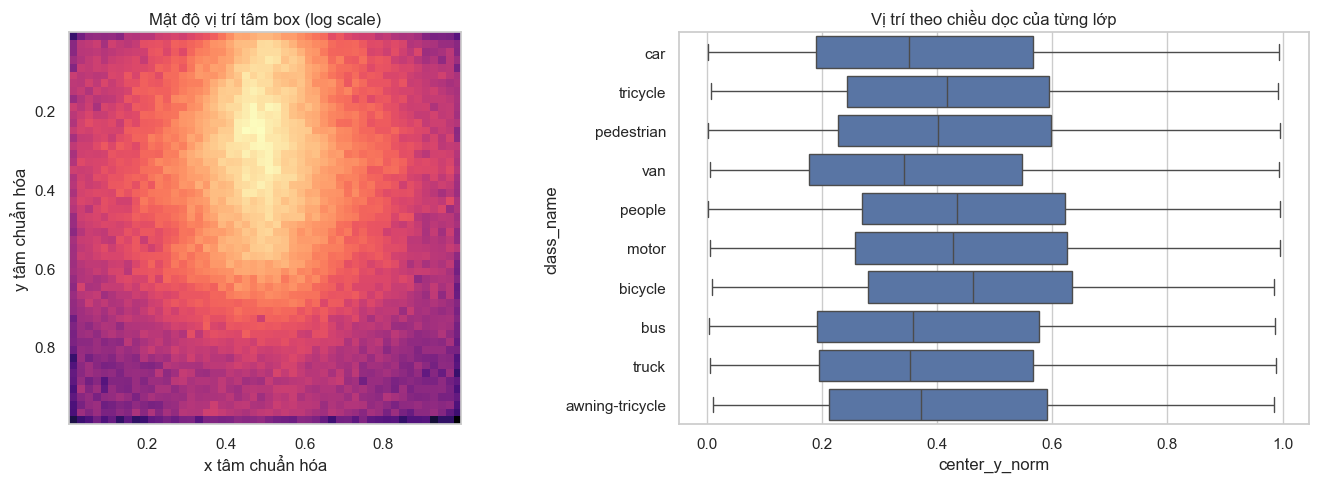

In [15]:
valid_boxes['center_x_norm'] = ((valid_boxes.x + valid_boxes.box_width / 2) / valid_boxes.image_width).clip(0, 1)
valid_boxes['center_y_norm'] = ((valid_boxes.y + valid_boxes.box_height / 2) / valid_boxes.image_height).clip(0, 1)
valid_boxes['width_norm'] = valid_boxes.clipped_width / valid_boxes.image_width
valid_boxes['height_norm'] = valid_boxes.clipped_height / valid_boxes.image_height
valid_boxes['touches_border'] = ((valid_boxes.x <= 0) | (valid_boxes.y <= 0) |
                                  (valid_boxes.x + valid_boxes.box_width >= valid_boxes.image_width) |
                                  (valid_boxes.y + valid_boxes.box_height >= valid_boxes.image_height))

spatial_summary = valid_boxes.groupby('class_name').agg(
    boxes=('image_id', 'size'), median_x=('center_x_norm', 'median'),
    median_y=('center_y_norm', 'median'),
    border_pct=('touches_border', lambda x: 100 * x.mean()),
).reindex(CLASS_NAMES.values())
display(spatial_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist2d(valid_boxes.center_x_norm, valid_boxes.center_y_norm, bins=50,
               norm=plt.matplotlib.colors.LogNorm(), cmap='magma')
axes[0].invert_yaxis(); axes[0].set_aspect('equal')
axes[0].set(xlabel='x tâm chuẩn hóa', ylabel='y tâm chuẩn hóa', title='Mật độ vị trí tâm box (log scale)')
sns.boxplot(data=valid_boxes.sample(min(60000, len(valid_boxes)), random_state=RANDOM_SEED),
            x='center_y_norm', y='class_name', showfliers=False, ax=axes[1])
axes[1].set_title('Vị trí theo chiều dọc của từng lớp')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 11

- Tâm box theo chiều ngang gần 0,5 cho mọi lớp, cho thấy không có lệch trái/phải mạnh.
- Các lớp xe lớn tập trung cao hơn trong ảnh (`median_y` khoảng 0,34–0,35), người và xe hai bánh thấp hơn (`median_y` khoảng 0,40–0,46).
- `bus` có tỷ lệ chạm biên cao nhất **7,01%**, tiếp theo là `truck` **5,99%**.

**Kết luận:** augmentation dịch chuyển nhẹ là hợp lý, nhưng crop phải bbox-safe. Phân bố dọc theo lớp phản ánh phối cảnh drone và nên được giữ, tránh biến đổi cực đoan phá ngữ cảnh đường.

## 12. Scale và hình dạng box theo từng lớp

Ngoài kích thước pixel, notebook dùng diện tích tương đối để so sánh công bằng giữa các độ phân giải. Ba nhóm scale phục vụ EDA là: `tiny < 0.1%`, `small = 0.1–1%`, `larger >= 1%` diện tích ảnh. Đây không phải ngưỡng COCO và pipeline không xóa nhóm nào.

,boxes,median_width_px,median_height_px,median_relative_area,p90_relative_area,median_aspect_ratio
class_name,,,,,,
pedestrian,109187,11.0,24.0,0.0002,0.0011,0.4615
people,38560,13.0,19.0,0.0002,0.0008,0.6316
bicycle,13069,23.0,25.0,0.0004,0.0015,0.8704
car,187004,37.0,29.0,0.0008,0.0049,1.2353
van,32702,38.0,33.0,0.0009,0.0054,1.1111
truck,16284,50.0,44.0,0.0016,0.0105,1.0435
tricycle,6387,35.0,31.0,0.0009,0.0038,1.0435
awning-tricycle,4377,35.0,35.0,0.0009,0.0039,0.9403
bus,9117,50.0,50.0,0.0021,0.0120,0.9167


scale_group,tiny <0.1%,small 0.1-1%,larger >=1%
class_name,,,
pedestrian,88.88,11.04,0.09
people,92.44,7.47,0.09
bicycle,81.38,18.45,0.17
car,57.20,39.31,3.49
van,52.56,43.44,4.00
truck,38.12,51.33,10.54
tricycle,53.97,44.61,1.42
awning-tricycle,54.51,43.55,1.94
bus,30.89,56.49,12.62


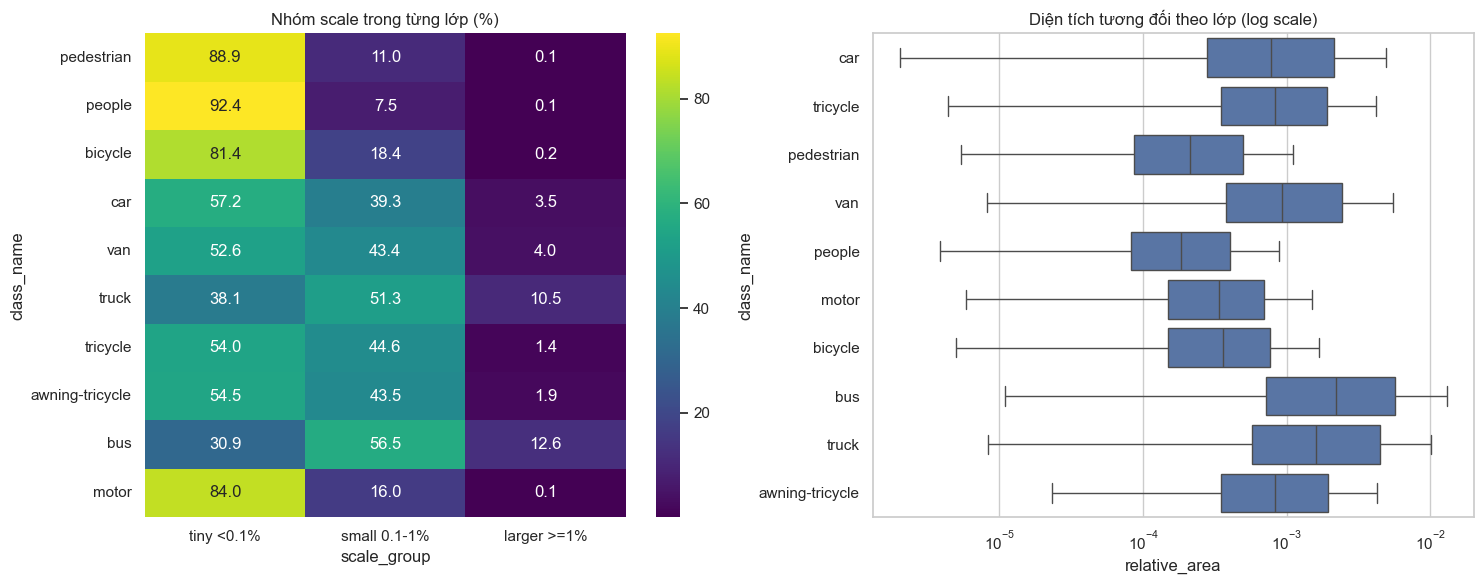

In [16]:
valid_boxes['scale_group'] = pd.cut(
    valid_boxes.relative_area, bins=[-np.inf, .001, .01, np.inf],
    labels=['tiny <0.1%', 'small 0.1-1%', 'larger >=1%'], right=False,
)
scale_by_class = 100 * pd.crosstab(valid_boxes.class_name, valid_boxes.scale_group, normalize='index')
scale_by_class = scale_by_class.reindex(CLASS_NAMES.values())
shape_by_class = valid_boxes.groupby('class_name').agg(
    boxes=('image_id', 'size'), median_width_px=('clipped_width', 'median'),
    median_height_px=('clipped_height', 'median'),
    median_relative_area=('relative_area', 'median'),
    p90_relative_area=('relative_area', lambda x: x.quantile(.9)),
    median_aspect_ratio=('aspect_ratio', 'median'),
).reindex(CLASS_NAMES.values())
display(shape_by_class.round(4)); display(scale_by_class.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(scale_by_class, annot=True, fmt='.1f', cmap='viridis', ax=axes[0])
axes[0].set_title('Nhóm scale trong từng lớp (%)')
plot_sample = valid_boxes.sample(min(70000, len(valid_boxes)), random_state=RANDOM_SEED)
sns.boxplot(data=plot_sample, x='relative_area', y='class_name', showfliers=False, ax=axes[1])
axes[1].set_xscale('log'); axes[1].set_title('Diện tích tương đối theo lớp (log scale)')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 12

- `people` có **92,44%** box tiny, `pedestrian` **88,88%**, `motor` **83,96%**, `bicycle` **81,38%**.
- `bus` và `truck` lớn hơn tương đối nhưng vẫn có lần lượt 30,89% và 38,12% thuộc nhóm tiny.
- Kích thước median của pedestrian chỉ 11×24 pixel; bus khoảng 50×50 pixel trên ảnh gốc.

**Kết luận:** vấn đề tiny-object ảnh hưởng mọi lớp, không chỉ người. AP-small phải là metric chính; lớp người/xe hai bánh cần input resolution cao và feature level có stride nhỏ.

## 13. Occlusion và truncation theo lớp, split và scale

Thống kê tổng ở phần 6 có thể che giấu việc một số lớp hiếm khó hơn rõ rệt. Bảng dưới tách tỷ lệ che khuất nhẹ/nặng và cắt cụt theo lớp; heatmap theo split kiểm tra xem validation có khó tương đương train hay không.

,boxes,occluded_pct,heavily_occluded_pct,truncated_pct
class_name,,,,
pedestrian,109187,37.21,5.22,1.92
people,38560,71.44,10.90,0.98
bicycle,13069,71.27,13.58,2.42
car,187004,48.27,10.31,5.44
van,32702,50.17,8.12,5.53
truck,16284,50.47,8.66,7.61
tricycle,6387,62.63,13.54,3.38
awning-tricycle,4377,56.66,13.05,4.36
bus,9117,48.89,9.10,9.63


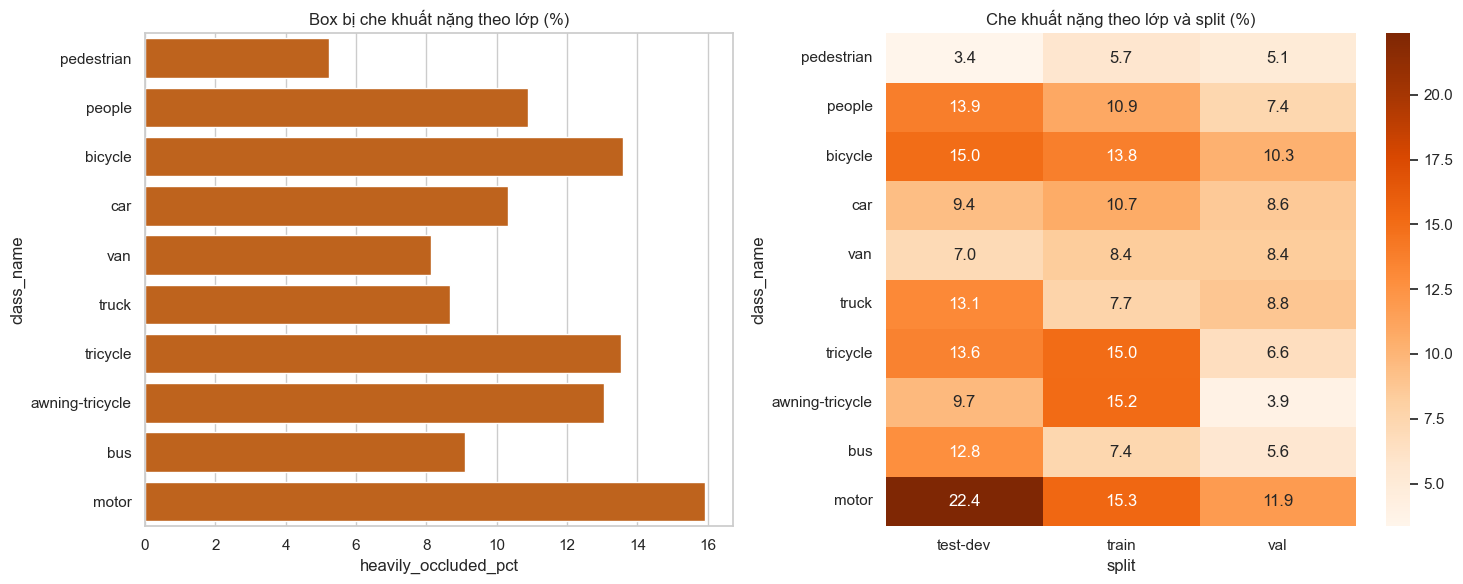

In [17]:
condition_by_class = valid_boxes.groupby('class_name').agg(
    boxes=('image_id', 'size'),
    occluded_pct=('occlusion', lambda x: 100 * (x > 0).mean()),
    heavily_occluded_pct=('occlusion', lambda x: 100 * (x == 2).mean()),
    truncated_pct=('truncation', lambda x: 100 * (x > 0).mean()),
).reindex(CLASS_NAMES.values())
display(condition_by_class.round(2))

occlusion_split = 100 * pd.crosstab(
    [valid_boxes.class_name, valid_boxes.split], valid_boxes.occlusion, normalize='index'
)
heavy_occlusion = occlusion_split.get(2, pd.Series(0, index=occlusion_split.index)).unstack('split')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=condition_by_class.reset_index(), x='heavily_occluded_pct', y='class_name',
            color='#d95f02', ax=axes[0])
axes[0].set_title('Box bị che khuất nặng theo lớp (%)')
sns.heatmap(heavy_occlusion.reindex(CLASS_NAMES.values()), annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Che khuất nặng theo lớp và split (%)')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 13

- `motor` có che khuất nặng cao nhất **15,92%**; `bicycle`, `tricycle`, `awning-tricycle` đều khoảng 13%.
- `people` và `bicycle` có hơn 71% box bị che khuất ở một mức nào đó.
- `bus` có truncation cao nhất **9,63%**, sau đó là `truck` **7,61%**.

**Kết luận:** AP thấp của các lớp này có thể đến từ điều kiện quan sát khó chứ không chỉ thiếu dữ liệu. Nên giữ nhãn khi train và phân tích lỗi/recall riêng theo occlusion và truncation.

## 14. Trùng ảnh, rò rỉ split và tương quan chuỗi video

- SHA-256 tìm ảnh trùng byte chính xác.
- Tên VisDrone có dạng gần giống `sequence_frame_d_id`; tiền tố đầu được dùng như dấu hiệu chuỗi nguồn.
- dHash chỉ sàng lọc các cặp train–val thuộc cùng tiền tố chuỗi. Khoảng cách nhỏ không tự động khẳng định rò rỉ, nhưng chỉ ra cặp cần xem thủ công.

Nếu cùng một cảnh/chuỗi video xuất hiện ở train và validation, metric có thể lạc quan dù không có ảnh trùng tuyệt đối.

In [18]:
from collections import defaultdict
import hashlib

image_index = images_df[['split', 'image_id', 'image_path', 'annotation_path']].copy()
image_index['sequence_prefix'] = image_index.image_id.str.split('_').str[0]
hash_groups = defaultdict(list)
for row in image_index.itertuples():
    digest = hashlib.sha256(Path(row.image_path).read_bytes()).hexdigest()
    hash_groups[digest].append(row)

duplicate_rows = []
for digest, rows in hash_groups.items():
    if len(rows) < 2:
        continue
    annotation_hashes = []
    for row in rows:
        path = Path(row.annotation_path) if row.annotation_path else None
        annotation_hashes.append(hashlib.sha256(path.read_bytes()).hexdigest() if path and path.exists() else None)
    duplicate_rows.append({
        'sha256_prefix': digest[:12], 'copies': len(rows),
        'splits': ', '.join(sorted({row.split for row in rows})),
        'image_ids': ', '.join(row.image_id for row in rows),
        'same_annotation': len(set(annotation_hashes)) == 1,
    })
duplicates_df = pd.DataFrame(duplicate_rows)
display(duplicates_df if len(duplicates_df) else pd.DataFrame({'result': ['Không có ảnh trùng byte']}))

sequence_sets = image_index.groupby('split').sequence_prefix.apply(set)
sequence_overlap_rows = []
for left, right in combinations(SPLITS, 2):
    overlap = sequence_sets[left] & sequence_sets[right]
    sequence_overlap_rows.append({'pair': f'{left} vs {right}', 'overlap_sequences': len(overlap),
                                  'examples': ', '.join(sorted(overlap)[:12])})
sequence_overlap_df = pd.DataFrame(sequence_overlap_rows)
display(sequence_overlap_df)

def difference_hash(path, hash_size=8):
    with Image.open(path) as image:
        pixels = np.asarray(image.convert('L').resize((hash_size + 1, hash_size)), dtype=np.int16)
    bits = (pixels[:, 1:] > pixels[:, :-1]).ravel()
    return sum(int(bit) << index for index, bit in enumerate(bits))

shared_train_val = sequence_sets['train'] & sequence_sets['val']
candidate_index = image_index[
    image_index.sequence_prefix.isin(shared_train_val) & image_index.split.isin(['train', 'val'])
].copy()
candidate_index['dhash'] = [difference_hash(path) for path in candidate_index.image_path]
near_pairs = []
for sequence, group in candidate_index.groupby('sequence_prefix'):
    train_rows = list(group[group.split == 'train'].itertuples())
    val_rows = list(group[group.split == 'val'].itertuples())
    for train_row in train_rows:
        for val_row in val_rows:
            distance = bin(train_row.dhash ^ val_row.dhash).count('1')
            near_pairs.append((distance, sequence, train_row.image_id, val_row.image_id))
near_pairs_df = pd.DataFrame(near_pairs, columns=['dhash_distance', 'sequence', 'train_image', 'val_image'])
display(near_pairs_df.nsmallest(15, 'dhash_distance'))
print('Số cặp train–val cùng sequence có dHash distance <= 6:', int((near_pairs_df.dhash_distance <= 6).sum()))

,sha256_prefix,copies,splits,image_ids,same_annotation
0,382de736b27a,2,train,"0000239_06450_d_0000017, 0000239_06950_d_0000018",False
1,094db39c7c57,2,train,"9999950_00000_d_0000079, 9999950_00000_d_10000080",False
2,0bea9d13456e,2,val,"0000022_00000_d_0000004, 0000023_00000_d_0000008",False


,pair,overlap_sequences,examples
0,train vs val,24,"0000072, 0000076, 0000165, 0000166, 0000196, 0..."
1,train vs test-dev,0,
2,val vs test-dev,0,


,dhash_distance,sequence,train_image,val_image
290,4,0000323,0000323_01801_d_0000641,0000323_02601_d_0000645
293,4,0000323,0000323_02401_d_0000644,0000323_02601_d_0000645
292,5,0000323,0000323_02201_d_0000643,0000323_02601_d_0000645
291,7,0000323,0000323_02001_d_0000642,0000323_02601_d_0000645
44,9,0000165,0000165_04125_d_0000104,0000165_04325_d_0000105
67,11,0000196,0000196_04071_d_0000143,0000196_04512_d_0000144
297,12,0000342,0000342_00589_d_0000245,0000342_00393_d_0000244
340,12,0000348,0000348_01373_d_0000413,0000348_00589_d_0000409
42,13,0000165,0000165_03725_d_0000102,0000165_04325_d_0000105
60,14,0000196,0000196_00553_d_0000136,0000196_04512_d_0000144


Số cặp train–val cùng sequence có dHash distance <= 6: 3


### Báo cáo tóm tắt và kết luận phần 14

- Có **3 nhóm ảnh trùng byte trong cùng split**, nhưng annotation của từng bản sao không giống nhau.
- Không có ảnh trùng byte xuyên split; tuy nhiên có **24 sequence prefix** chung giữa train và validation.
- Có **3 cặp train–val cùng sequence với dHash ≤6**, cho thấy nội dung thị giác rất gần nhau.

**Kết luận:** official split vẫn dùng cho benchmark, nhưng có nguy cơ metric lạc quan do tương quan sequence. Cần xem thủ công các duplicate/near-duplicate và làm thêm sequence-aware evaluation nếu mục tiêu là cảnh mới.

## 15. Chất lượng hình ảnh: độ sáng, tương phản, độ sắc nét và màu

Để giữ thời gian chạy hợp lý, phần này lấy mẫu có seed cố định trong từng split. `sharpness_proxy` là trung bình gradient tuyệt đối trên ảnh grayscale thu nhỏ; nó dùng để so sánh tương đối và tìm ảnh mờ, không phải một thước đo chất lượng tuyệt đối.

brightness                         contrast                          \
               mean     std     min     max     mean     std     min     max   
split                                                                          
test-dev     0.3447  0.1453  0.0803  0.7655   0.1744  0.0405  0.0733  0.2965   
train        0.3693  0.1327  0.0789  0.7917   0.1709  0.0445  0.0166  0.2939   
val          0.4518  0.0822  0.1821  0.7294   0.1768  0.0440  0.0618  0.3138   

         sharpness_proxy                         red_mean                  \
                    mean     std     min     max     mean     std     min   
split                                                                       
test-dev          0.0400  0.0129  0.0082  0.0814   0.3454  0.1401  0.0788   
train             0.0377  0.0136  0.0045  0.0797   0.3710  0.1277  0.0886   
val               0.0361  0.0093  0.0109  0.0607   0.4435  0.0808  0.1915   

                 green_mean                         blue_mean                  \
             max       mean     std     min     max      mean     std     min   
split                                                                           
test-dev  0.7778     0.3470  0.1485  0.0702  0.7665    0.3416  0.1515  0.0756   
train     0.8594     0.3741  0.1405  0.0622  0.8083    0.3628  0.1345  0.0656   
val       0.7245     0.4658  0.0847  0.1622  0.7432    0.4461  0.0873  0.1480   

                  
             max  
split             
test-dev  0.8703  
train     0.7285  
val       0.7205

,split,image_id,brightness,contrast,sharpness_proxy
292,train,0000040_02454_d_0000068,0.0939,0.0166,0.0045
18,test-dev,9999996_00000_d_0000019,0.3563,0.2965,0.0082
106,test-dev,9999996_00000_d_0000024,0.3663,0.2882,0.0097
271,train,9999950_00000_d_0000082,0.0789,0.0725,0.0098
161,test-dev,9999996_00000_d_0000023,0.3520,0.2725,0.0099
379,train,9999950_00000_d_0000017,0.0959,0.0876,0.0108
550,val,0000360_04705_d_0000737,0.5623,0.0618,0.0109
250,train,9999945_00000_d_0000073,0.1409,0.0739,0.0110
254,train,9999997_00000_d_0000027,0.3553,0.2646,0.0112
239,test-dev,9999996_00000_d_0000021,0.3666,0.2750,0.0115


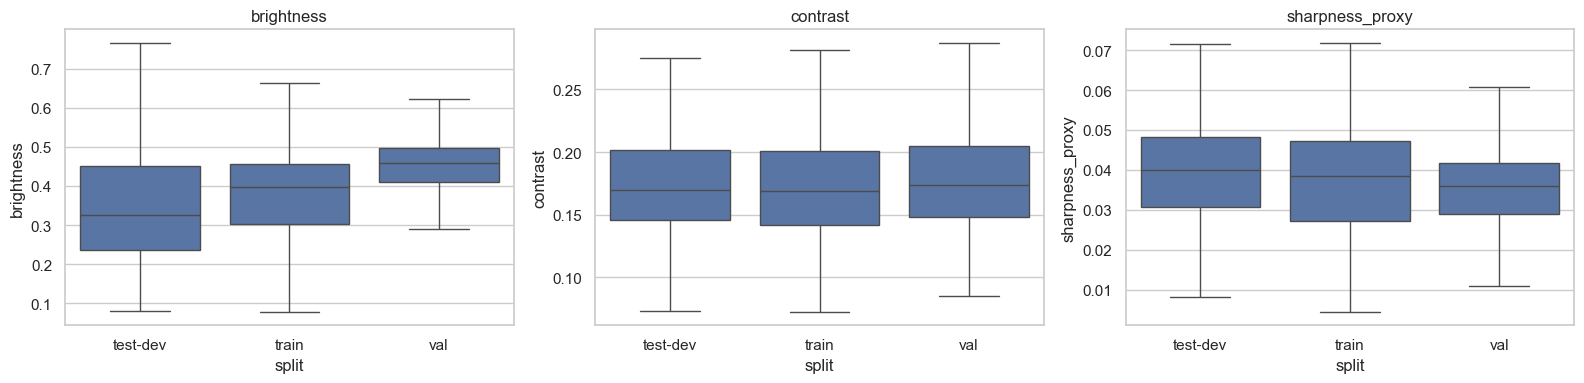

In [19]:
quality_rows = []
sample_per_split = 250
for split, frame in images_df.groupby('split'):
    selected = frame.sample(min(sample_per_split, len(frame)), random_state=RANDOM_SEED)
    for row in selected.itertuples():
        with Image.open(row.image_path) as image:
            rgb = np.asarray(image.convert('RGB').resize((256, 144)), dtype=np.float32) / 255
        gray = rgb.mean(axis=2)
        sharpness = (np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()) / 2
        quality_rows.append({
            'split': split, 'image_id': row.image_id, 'image_path': row.image_path,
            'brightness': gray.mean(), 'contrast': gray.std(), 'sharpness_proxy': sharpness,
            'red_mean': rgb[..., 0].mean(), 'green_mean': rgb[..., 1].mean(), 'blue_mean': rgb[..., 2].mean(),
        })
quality_df = pd.DataFrame(quality_rows)
display(quality_df.groupby('split')[['brightness', 'contrast', 'sharpness_proxy',
                                     'red_mean', 'green_mean', 'blue_mean']].agg(['mean', 'std', 'min', 'max']).round(4))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for metric, ax in zip(['brightness', 'contrast', 'sharpness_proxy'], axes):
    sns.boxplot(data=quality_df, x='split', y=metric, showfliers=False, ax=ax); ax.set_title(metric)
plt.tight_layout()
display(quality_df.nsmallest(10, 'sharpness_proxy')[
    ['split', 'image_id', 'brightness', 'contrast', 'sharpness_proxy']].round(4))

### Báo cáo tóm tắt và kết luận phần 15

- Trên mẫu cố định, validation sáng hơn rõ rệt: brightness trung bình **0,4518**, so với train **0,3693** và test-dev **0,3447**.
- Contrast trung bình khá gần nhau; sharpness proxy của validation thấp hơn nhẹ.
- Đã xác định danh sách ảnh có sharpness thấp để kiểm tra thủ công.

**Kết luận:** nên dùng brightness/contrast/color jitter và blur nhẹ trong train để tăng robustness. Đây là thống kê trên mẫu 250 ảnh/split nên dùng để định hướng, không xem là kiểm định tuyệt đối toàn dataset.

## 16. Đồng xuất hiện giữa các lớp

Jaccard ở cấp ảnh đo tỷ lệ ảnh chứa đồng thời hai lớp trên số ảnh chứa ít nhất một trong hai. Phân tích này giúp lựa chọn augmentation và đọc lỗi mô hình: các lớp thường đi cùng nhau có thể tạo ngữ cảnh hữu ích nhưng cũng gây nhầm lẫn.

,jaccard,class_1,class_2
0,0.790,car,van
1,0.771,pedestrian,car
2,0.718,people,motor
3,0.669,pedestrian,van
4,0.658,pedestrian,motor
5,0.645,pedestrian,people
6,0.639,car,motor
7,0.587,van,motor
8,0.586,people,car
9,0.548,car,truck


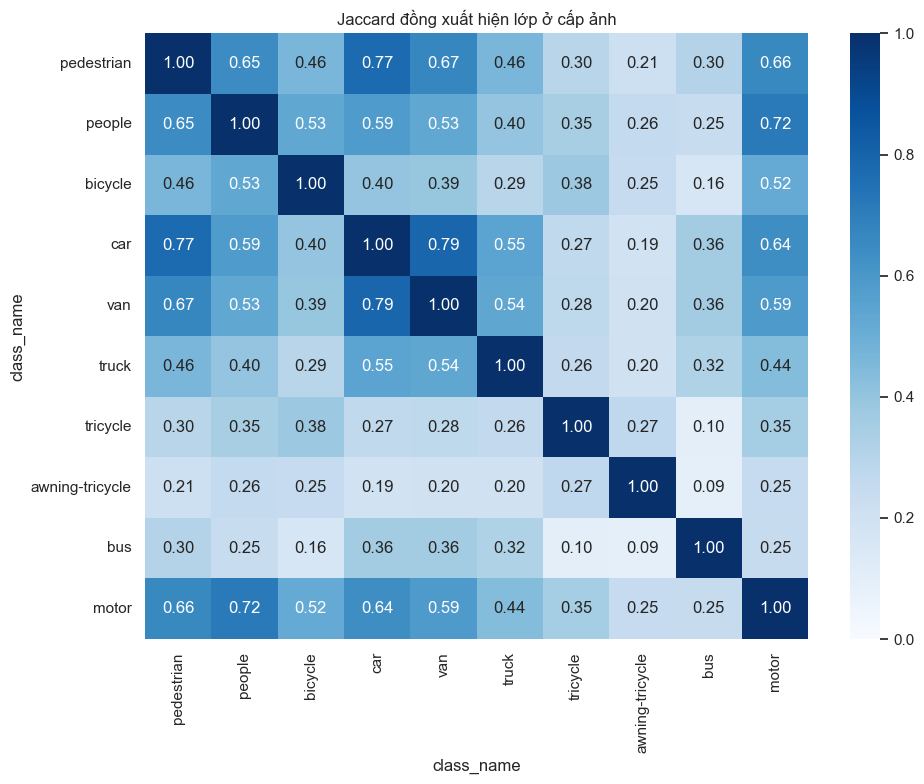

In [20]:
presence_matrix = (image_presence.assign(value=1)
                   .pivot_table(index=['split', 'image_id'], columns='class_name', values='value', fill_value=0)
                   .reindex(columns=CLASS_NAMES.values(), fill_value=0).astype(bool))
jaccard = pd.DataFrame(index=presence_matrix.columns, columns=presence_matrix.columns, dtype=float)
for left in presence_matrix.columns:
    for right in presence_matrix.columns:
        union = (presence_matrix[left] | presence_matrix[right]).sum()
        intersection = (presence_matrix[left] & presence_matrix[right]).sum()
        jaccard.loc[left, right] = intersection / union if union else 0
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Jaccard đồng xuất hiện lớp ở cấp ảnh'); plt.tight_layout()
pairs = []
for i, left in enumerate(jaccard.columns):
    for right in jaccard.columns[i + 1:]:
        pairs.append((jaccard.loc[left, right], left, right))
display(pd.DataFrame(sorted(pairs, reverse=True)[:15], columns=['jaccard', 'class_1', 'class_2']).round(3))

### Báo cáo tóm tắt và kết luận phần 16

- Đồng xuất hiện mạnh nhất là `car–van` (**Jaccard 0,790**), `pedestrian–car` (**0,771**) và `people–motor` (**0,718**).
- Các nhóm người, xe máy, xe đạp thường xuất hiện cùng nhau; xe tải/van/car cũng chia sẻ ngữ cảnh giao thông.
- Oversample cả ảnh chứa lớp hiếm có thể đồng thời tăng exposure của nhiều lớp phổ biến.

**Kết luận:** ngữ cảnh là tín hiệu hữu ích nhưng dễ tạo shortcut. Targeted copy-paste cần đặt object vào nền hợp lý; image-level oversampling phải được kiểm tra hiệu ứng đồng xuất hiện.

## 17. Các ảnh cực trị cần xem thủ công

Không chỉ xem mẫu ngẫu nhiên: EDA tốt cần kiểm tra ảnh đông nhất, ảnh có box nhỏ nhất, ảnh mờ nhất và ảnh chứa lớp hiếm. Bảng này tạo danh sách audit có thể mở trực tiếp từ `image_path`.

,reason,split,image_id,trainable_objects,min_relative_area,max_occlusion,sharpness_proxy,image_path
221,crowded,train,0000137_02220_d_0000163,512,0.00003,2,NaN,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
7477,crowded,test-dev,9999938_00000_d_0000207,461,0.00001,2,NaN,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
264,crowded,train,0000143_01681_d_0000056,462,0.00002,2,NaN,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
51,crowded,train,0000059_01886_d_0000114,902,0.00001,2,NaN,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
196,crowded,train,0000126_11844_d_0000130,431,0.00001,2,NaN,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
8618,low_sharpness_sample,test-dev,9999996_00000_d_0000019,17,0.00044,1,0.00819,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
2323,low_sharpness_sample,train,9999950_00000_d_0000082,17,0.00004,2,0.00983,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
8622,low_sharpness_sample,test-dev,9999996_00000_d_0000023,15,0.00001,1,0.00990,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
8623,low_sharpness_sample,test-dev,9999996_00000_d_0000024,59,0.00002,2,0.00967,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...
31,low_sharpness_sample,train,0000040_02454_d_0000068,19,0.00108,0,0.00446,/Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Obje...


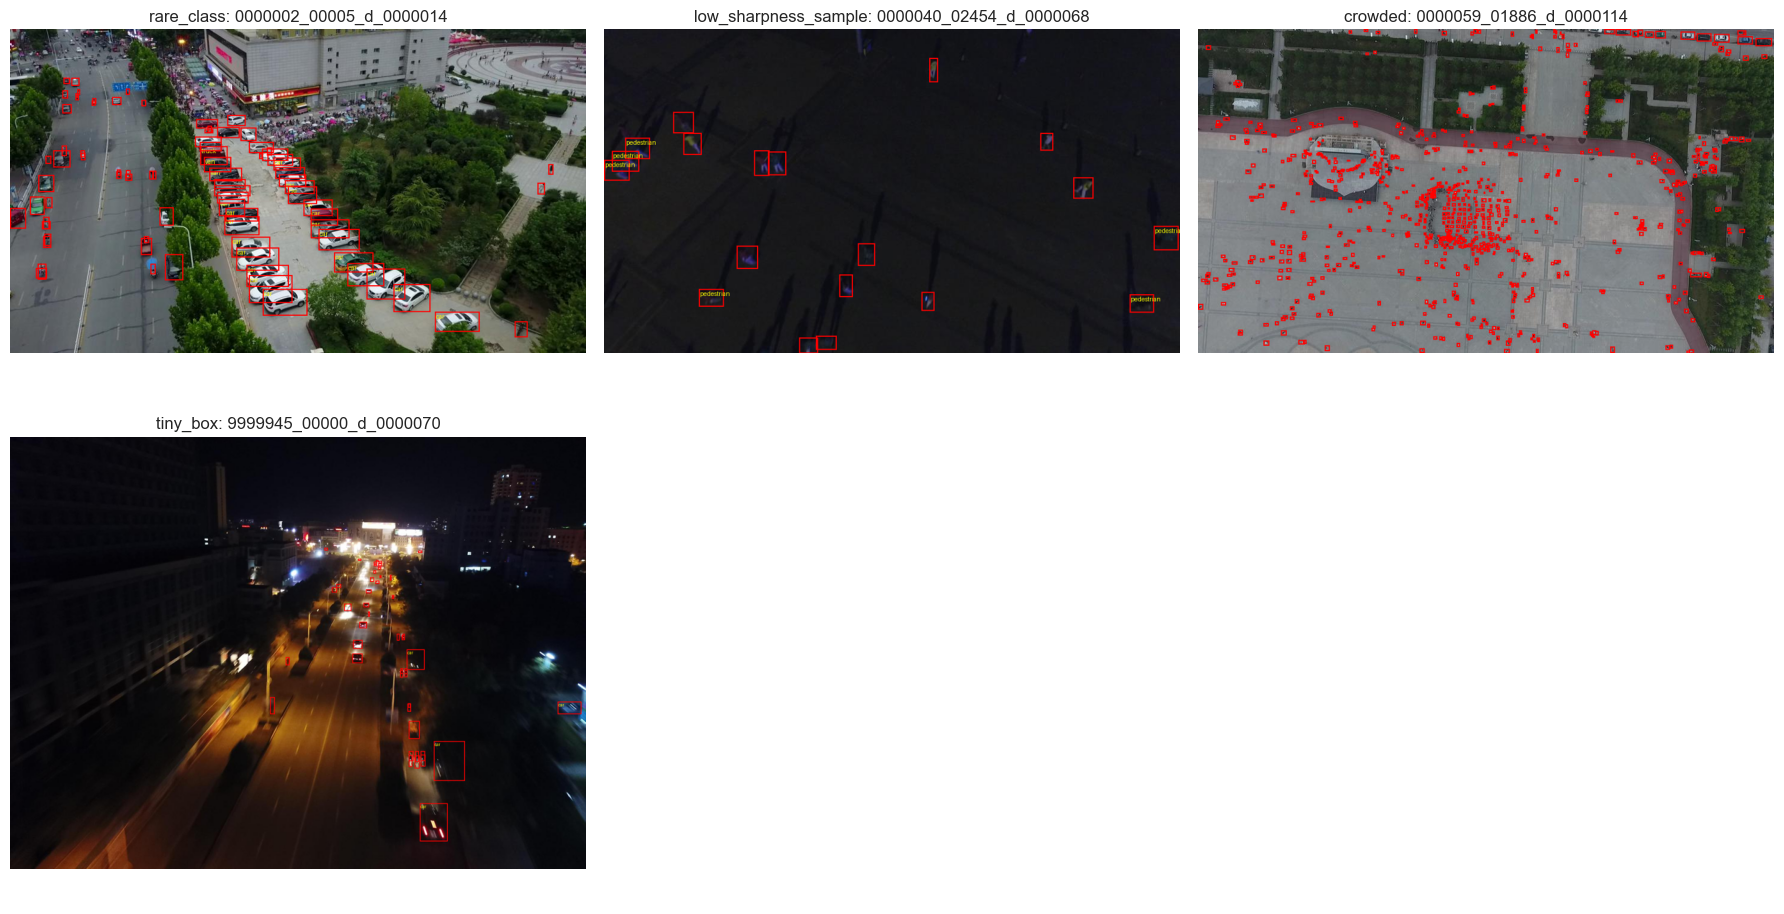

In [21]:
image_box_stats = valid_boxes.groupby(['split', 'image_id']).agg(
    min_relative_area=('relative_area', 'min'), median_relative_area=('relative_area', 'median'),
    max_occlusion=('occlusion', 'max'),
).reset_index()
audit_table = images_df.merge(image_box_stats, on=['split', 'image_id'], how='left')
audit_table = audit_table.merge(quality_df[['split', 'image_id', 'sharpness_proxy']],
                                on=['split', 'image_id'], how='left')
extreme_ids = set(audit_table.nlargest(5, 'trainable_objects').image_id)
extreme_ids.update(audit_table.nsmallest(5, 'min_relative_area').image_id)
extreme_ids.update(quality_df.nsmallest(5, 'sharpness_proxy').image_id)
rare_classes = class_counts.nsmallest(3, 'objects').class_name.tolist()
rare_ids = (valid_boxes[valid_boxes.class_name.isin(rare_classes)]
            .drop_duplicates(['class_name', 'image_id'])
            .groupby('class_name', group_keys=False).head(3).image_id)
extreme_ids.update(rare_ids)
audit_cases = audit_table[audit_table.image_id.isin(extreme_ids)].copy()
audit_cases['reason'] = np.select(
    [audit_cases.trainable_objects >= audit_table.trainable_objects.nlargest(5).min(),
     audit_cases.min_relative_area <= audit_table.min_relative_area.nsmallest(5).max(),
     audit_cases.sharpness_proxy <= quality_df.sharpness_proxy.nsmallest(5).max()],
    ['crowded', 'tiny_box', 'low_sharpness_sample'], default='rare_class')
display(audit_cases[['reason', 'split', 'image_id', 'trainable_objects', 'min_relative_area',
                     'max_occlusion', 'sharpness_proxy', 'image_path']].sort_values('reason').round(5))

show_rows = audit_cases.drop_duplicates('reason').head(6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax in axes.flat: ax.axis('off')
for ax, (_, row) in zip(axes.flat, show_rows.iterrows()):
    preview = draw_visdrone_sample(row); preview.thumbnail((900, 600))
    ax.imshow(preview); ax.set_title(f'{row.reason}: {row.image_id}'); ax.axis('off')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 17

- Bộ audit bao phủ bốn nhóm: ảnh đông object, box cực nhỏ, ảnh có sharpness thấp và ảnh chứa lớp hiếm.
- Ảnh đông nhất có 902 object; nhiều ảnh cực trị đồng thời có occlusion nặng.
- Các trường hợp này khó hơn mẫu ngẫu nhiên và phù hợp để theo dõi lỗi xuyên suốt thí nghiệm.

**Kết luận:** giữ cố định danh sách audit để so sánh qualitative giữa Faster R-CNN, YOLO và RT-DETR. Không chỉ trình bày ảnh dự đoán đẹp; cần đưa cả false positive, false negative và cảnh cực đông.

## 18. Kích thước object sau letterbox và giới hạn số prediction

Kích thước trên ảnh gốc chưa phản ánh tín hiệu thật đi vào model. Cell này mô phỏng letterbox vuông tại `640`, `960`, `1280` (giữ aspect ratio, thêm padding) và đo cạnh ngắn của box sau resize. Box dưới 4–8 pixel đặc biệt khó phát hiện.

Đồng thời, số ground-truth trên mỗi ảnh được so với các giới hạn thường gặp: Faster R-CNN `box_detections_per_img=100`, YOLO `max_det=300`, RT-DETR `num_queries=300`. Đây là giới hạn cấu hình cần kiểm tra, không phải lỗi dataset.

,median_width_px,median_height_px,short_side_<4px_%,short_side_<8px_%,short_side_<16px_%,short_side_<32px_%
input_size,,,,,,
640,10.35,11.43,16.65,46.63,77.88,94.58
960,15.53,17.14,6.18,27.63,61.60,86.93
1280,20.71,22.86,3.12,16.65,46.63,77.88


,median_px,p10_px,under_8px_pct,under_16px_pct
class_name,,,,
pedestrian,7.54,3.43,52.39,86.07
people,8.23,3.50,47.43,86.44
bicycle,11.66,4.80,28.36,70.37
car,16.46,6.35,15.77,48.09
van,18.35,8.00,9.99,42.40
truck,23.31,9.52,6.48,30.42
tricycle,17.83,7.52,11.40,42.63
awning-tricycle,18.35,7.52,11.40,41.24
bus,24.96,9.60,5.57,27.52


,images,max_objects,>100_objects,>100_%,>300_objects,>300_%,>500_objects
split,,,,,,,
test-dev,1610,461,127,7.89,7,0.43,0
train,6471,902,703,10.86,12,0.19,2
val,548,317,107,19.53,3,0.55,0


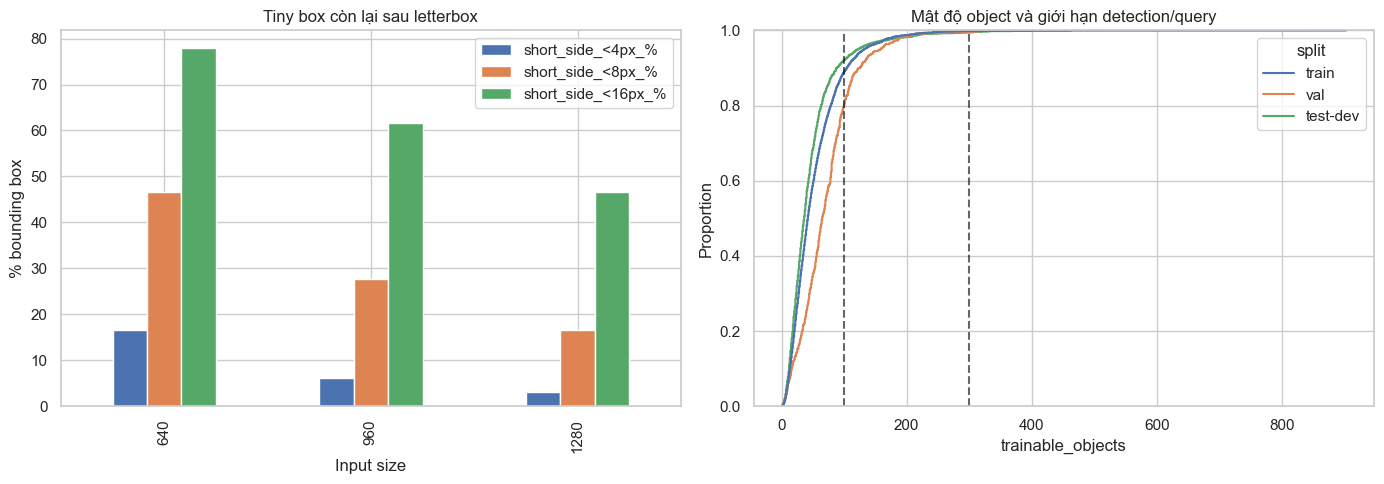

In [22]:
input_size_rows = []
for input_size in (640, 960, 1280):
    scale = np.minimum(input_size / valid_boxes.image_width, input_size / valid_boxes.image_height)
    input_width = valid_boxes.clipped_width * scale
    input_height = valid_boxes.clipped_height * scale
    short_side = np.minimum(input_width, input_height)
    input_size_rows.append({
        'input_size': input_size,
        'median_width_px': np.median(input_width),
        'median_height_px': np.median(input_height),
        'short_side_<4px_%': 100 * np.mean(short_side < 4),
        'short_side_<8px_%': 100 * np.mean(short_side < 8),
        'short_side_<16px_%': 100 * np.mean(short_side < 16),
        'short_side_<32px_%': 100 * np.mean(short_side < 32),
    })
input_size_df = pd.DataFrame(input_size_rows).set_index('input_size')
display(input_size_df.round(2))

scale_960 = np.minimum(960 / valid_boxes.image_width, 960 / valid_boxes.image_height)
short_side_960 = np.minimum(valid_boxes.clipped_width * scale_960,
                            valid_boxes.clipped_height * scale_960)
size_by_class_960 = (valid_boxes.assign(short_side_960=short_side_960)
                     .groupby('class_name').short_side_960
                     .agg(median_px='median', p10_px=lambda x: x.quantile(.1),
                          under_8px_pct=lambda x: 100 * (x < 8).mean(),
                          under_16px_pct=lambda x: 100 * (x < 16).mean())
                     .reindex(CLASS_NAMES.values()))
display(size_by_class_960.round(2))

capacity_rows = []
for split, frame in images_df.groupby('split'):
    capacity_rows.append({
        'split': split, 'images': len(frame), 'max_objects': frame.trainable_objects.max(),
        '>100_objects': int((frame.trainable_objects > 100).sum()),
        '>100_%': 100 * (frame.trainable_objects > 100).mean(),
        '>300_objects': int((frame.trainable_objects > 300).sum()),
        '>300_%': 100 * (frame.trainable_objects > 300).mean(),
        '>500_objects': int((frame.trainable_objects > 500).sum()),
    })
capacity_df = pd.DataFrame(capacity_rows).set_index('split')
display(capacity_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
input_size_df[['short_side_<4px_%', 'short_side_<8px_%', 'short_side_<16px_%']].plot(
    kind='bar', ax=axes[0])
axes[0].set(title='Tiny box còn lại sau letterbox', ylabel='% bounding box', xlabel='Input size')
sns.ecdfplot(data=images_df, x='trainable_objects', hue='split', ax=axes[1])
for limit in (100, 300): axes[1].axvline(limit, linestyle='--', color='black', alpha=.6)
axes[1].set_title('Mật độ object và giới hạn detection/query')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 18

- Sau letterbox 640, **46,63%** box có cạnh ngắn dưới 8 pixel; tại 960 còn **27,63%**, tại 1280 còn **16,65%**.
- Ở input 960, pedestrian/people vẫn có khoảng một nửa box dưới 8 pixel; motor và bicycle khoảng 28%.
- 10,86% ảnh train và 19,53% ảnh val có hơn 100 object; 22 ảnh toàn bộ dataset có hơn 300 object.

**Kết luận:** dùng 640 làm baseline tốc độ, 960 làm baseline chính và 1280 làm ablation AP-small. Cần tăng `box_detections_per_img`, `max_det` hoặc `num_queries` để tránh giới hạn recall trên cảnh đông.

## 19. Anchor coverage cho Faster R-CNN

Phân tích shape-IoU bỏ qua vị trí tâm và đo mức phù hợp giữa kích thước ground-truth sau letterbox 960 với hai bộ anchor:

- `default`: sizes 32–512 pixel.
- `small-object`: sizes 8–128 pixel.

Đây là chẩn đoán dữ liệu để chọn anchor proposal; kết quả cuối vẫn phải được xác nhận bằng ablation khi train Faster R-CNN.

In [23]:
def anchor_shapes(sizes, ratios=(0.5, 1.0, 2.0)):
    return np.array([(size / np.sqrt(ratio), size * np.sqrt(ratio))
                     for size in sizes for ratio in ratios], dtype=np.float32)

def best_shape_iou(widths, heights, anchors):
    widths = np.asarray(widths, dtype=np.float32)[:, None]
    heights = np.asarray(heights, dtype=np.float32)[:, None]
    intersection = np.minimum(widths, anchors[:, 0]) * np.minimum(heights, anchors[:, 1])
    union = widths * heights + anchors[:, 0] * anchors[:, 1] - intersection
    return (intersection / union).max(axis=1)

box_width_960 = valid_boxes.clipped_width.to_numpy() * scale_960.to_numpy()
box_height_960 = valid_boxes.clipped_height.to_numpy() * scale_960.to_numpy()
anchor_sets = {
    'default_32_to_512': anchor_shapes((32, 64, 128, 256, 512)),
    'small_8_to_128': anchor_shapes((8, 16, 32, 64, 128)),
}
anchor_rows = []
for name, anchors in anchor_sets.items():
    best_iou = best_shape_iou(box_width_960, box_height_960, anchors)
    anchor_rows.append({
        'anchor_set': name, 'median_best_iou': np.median(best_iou),
        'coverage_iou>=0.3_%': 100 * np.mean(best_iou >= .3),
        'coverage_iou>=0.5_%': 100 * np.mean(best_iou >= .5),
        'coverage_iou>=0.7_%': 100 * np.mean(best_iou >= .7),
    })
anchor_coverage_df = pd.DataFrame(anchor_rows).set_index('anchor_set')
display(anchor_coverage_df.round(2))

small_anchor_iou = best_shape_iou(box_width_960, box_height_960, anchor_sets['small_8_to_128'])
anchor_by_class = (valid_boxes.assign(best_anchor_iou=small_anchor_iou)
                   .groupby('class_name').best_anchor_iou
                   .agg(median_iou='median', coverage_05_pct=lambda x: 100 * (x >= .5).mean())
                   .reindex(CLASS_NAMES.values()))
display(anchor_by_class.round(2))

,median_best_iou,coverage_iou>=0.3_%,coverage_iou>=0.5_%,coverage_iou>=0.7_%
anchor_set,,,,
default_32_to_512,0.26,46.30,33.52,16.41
small_8_to_128,0.68,96.18,91.76,45.40


,median_iou,coverage_05_pct
class_name,,
pedestrian,0.64,83.99
people,0.66,83.87
bicycle,0.69,93.66
car,0.69,95.34
van,0.70,97.74
truck,0.69,97.59
tricycle,0.70,97.68
awning-tricycle,0.70,97.19
bus,0.69,97.86


### Báo cáo tóm tắt và kết luận phần 19

- Anchor mặc định 32–512 chỉ đạt **33,52% coverage** tại shape-IoU ≥0,5; median best IoU là 0,26.
- Bộ anchor nhỏ 8–128 đạt **91,76% coverage**, median best IoU 0,68.
- Với anchor nhỏ, coverage của hầu hết lớp trên 92%; pedestrian/people thấp hơn nhưng vẫn khoảng 84%.

**Kết luận:** Faster R-CNN cần ablation anchor sizes `(8,16,32,64,128)` thay vì giữ mặc định. Đây là thay đổi có cơ sở dữ liệu mạnh nhất cho baseline CNN.

## 20. Mô phỏng tiling cho small-object inference

Mô phỏng tile vuông trên ảnh gốc với overlap 20%, sau đó resize mỗi tile lên 960. Chỉ số `fully_contained_%` cho biết box có nằm trọn trong ít nhất một tile hay không; overlap giúp giảm object bị cắt ở biên. `tile_multiplier` là số lượt inference trung bình so với một ảnh gốc.

,overlap,tile_multiplier,fully_contained_%,median_short_side_at_960,short_side_<8px_%,short_side_<16px_%
tile_size,,,,,,
512,0.2,11.15,99.40,35.62,3.06,15.28
640,0.2,6.59,99.81,28.50,5.60,22.28
768,0.2,5.73,99.89,23.75,8.57,29.17


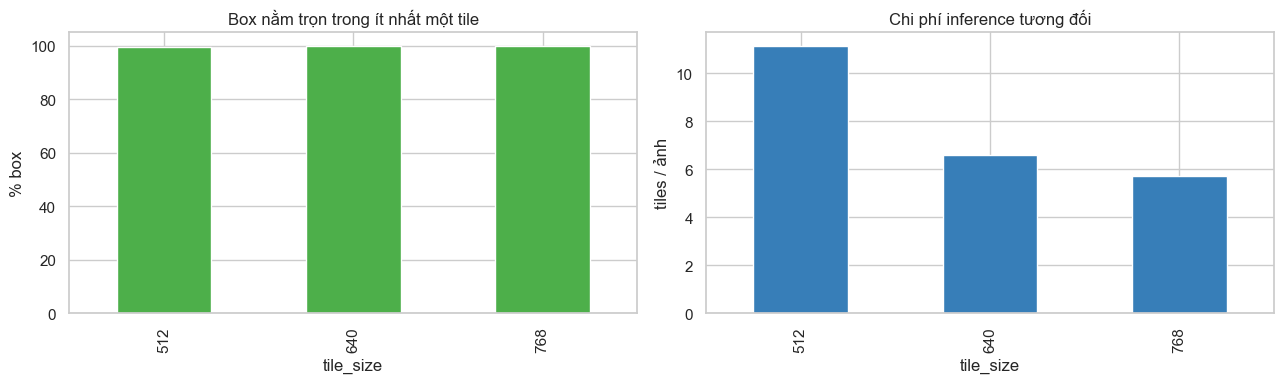

In [24]:
def tile_starts(length, tile_size, overlap):
    if length <= tile_size:
        return np.array([0.0])
    stride = max(1, int(round(tile_size * (1 - overlap))))
    starts = list(range(0, max(1, length - tile_size + 1), stride))
    last = length - tile_size
    if starts[-1] != last: starts.append(last)
    return np.asarray(starts, dtype=float)

def simulate_tiling(tile_size, overlap=.2, model_input=960):
    fully_contained = 0
    total_boxes = 0
    total_tiles = 0
    short_sides = []
    grouped_boxes = valid_boxes.groupby(['split', 'image_id'], sort=False)
    for row in images_df.itertuples():
        x_starts = tile_starts(row.width, tile_size, overlap)
        y_starts = tile_starts(row.height, tile_size, overlap)
        total_tiles += len(x_starts) * len(y_starts)
        group = grouped_boxes.get_group((row.split, row.image_id))
        x1 = group.x.to_numpy(); y1 = group.y.to_numpy()
        x2 = x1 + group.box_width.to_numpy(); y2 = y1 + group.box_height.to_numpy()
        contained = np.zeros(len(group), dtype=bool)
        for tile_x in x_starts:
            for tile_y in y_starts:
                contained |= ((x1 >= tile_x) & (y1 >= tile_y)
                              & (x2 <= tile_x + tile_size) & (y2 <= tile_y + tile_size))
        fully_contained += contained.sum(); total_boxes += len(group)
        effective_width = min(tile_size, row.width)
        effective_height = min(tile_size, row.height)
        scale = model_input / max(effective_width, effective_height)
        short_sides.extend(np.minimum(group.clipped_width, group.clipped_height) * scale)
    short_sides = np.asarray(short_sides)
    return {
        'tile_size': tile_size, 'overlap': overlap,
        'tile_multiplier': total_tiles / len(images_df),
        'fully_contained_%': 100 * fully_contained / total_boxes,
        'median_short_side_at_960': np.median(short_sides),
        'short_side_<8px_%': 100 * np.mean(short_sides < 8),
        'short_side_<16px_%': 100 * np.mean(short_sides < 16),
    }

tiling_df = pd.DataFrame([simulate_tiling(size) for size in (512, 640, 768)]).set_index('tile_size')
display(tiling_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tiling_df[['fully_contained_%']].plot(kind='bar', legend=False, ax=axes[0], color='#4daf4a')
axes[0].set(title='Box nằm trọn trong ít nhất một tile', ylabel='% box')
tiling_df[['tile_multiplier']].plot(kind='bar', legend=False, ax=axes[1], color='#377eb8')
axes[1].set(title='Chi phí inference tương đối', ylabel='tiles / ảnh')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 20

- Tile 512 giúp cạnh ngắn median lên **35,62 pixel** và chỉ còn 3,06% box dưới 8 pixel, nhưng tốn trung bình **11,15 lượt inference/ảnh**.
- Tile 640 đạt 99,81% box nằm trọn, 5,60% box dưới 8 pixel, chi phí **6,59×**.
- Tile 768 đạt 99,89% box nằm trọn, 8,57% box dưới 8 pixel, chi phí **5,73×**.

**Kết luận:** whole-image 960 dùng làm baseline; tile 768/overlap 20% phù hợp cân bằng tốc độ, tile 640 ưu tiên accuracy. Tiling phải được báo cáo cùng latency vì chi phí tăng đáng kể.

## 21. Mô phỏng rare-class sampling cho augmentation

Geometric/color augmentation làm dữ liệu đa dạng hơn nhưng không tự sửa mất cân bằng lớp. Cell này mô phỏng Repeat-Factor Sampling ở cấp ảnh với ngưỡng `t=0.1`: ảnh chứa lớp hiếm được lấy mẫu thường xuyên hơn, nhưng hệ số bị giới hạn ở 3× để tránh overfit. Nếu mọi repeat factor vẫn bằng 1, điều đó chứng tỏ lớp hiếm theo số box vẫn xuất hiện trong nhiều ảnh; oversample cả ảnh không giải quyết được và targeted copy-paste phù hợp hơn.

,image_frequency_%,repeat_factor,weighted_exposure_%,exposure_gain_x
pedestrian,82.92,1.0,82.92,1.0
people,61.00,1.0,61.00,1.0
bicycle,42.57,1.0,42.57,1.0
car,94.78,1.0,94.78,1.0
van,76.46,1.0,76.46,1.0
truck,54.88,1.0,54.88,1.0
tricycle,26.09,1.0,26.09,1.0
awning-tricycle,17.79,1.0,17.79,1.0
bus,31.26,1.0,31.26,1.0
motor,65.48,1.0,65.48,1.0


Kết luận: không nên oversample toàn ảnh ở t=0.1; ưu tiên targeted copy-paste theo instance.


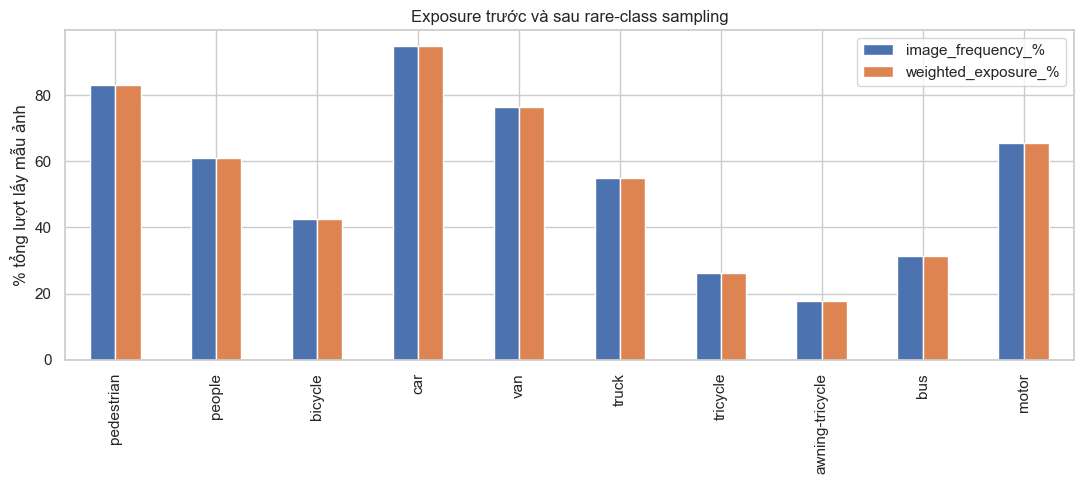

In [25]:
presence = valid_boxes[['split', 'image_id', 'class_name']].drop_duplicates()
train_presence = presence[presence.split == 'train']
train_image_ids = images_df.loc[images_df.split == 'train', 'image_id']
image_frequency = (train_presence.groupby('class_name').image_id.nunique() / len(train_image_ids))
repeat_by_class = np.maximum(1.0, np.sqrt(0.1 / image_frequency)).clip(upper=3.0)

classes_by_image = train_presence.groupby('image_id').class_name.apply(set)
image_repeat = classes_by_image.apply(
    lambda classes: max([repeat_by_class[name] for name in classes], default=1.0)
)
weighted_exposure = {}
for class_name in CLASS_NAMES.values():
    containing = set(train_presence.loc[train_presence.class_name == class_name, 'image_id'])
    weighted_exposure[class_name] = image_repeat[image_repeat.index.isin(containing)].sum() / image_repeat.sum()

sampling_df = pd.DataFrame({
    'image_frequency_%': 100 * image_frequency,
    'repeat_factor': repeat_by_class,
    'weighted_exposure_%': 100 * pd.Series(weighted_exposure),
}).reindex(CLASS_NAMES.values())
sampling_df['exposure_gain_x'] = (
    sampling_df['weighted_exposure_%'] / sampling_df['image_frequency_%']
)
display(sampling_df.round(2))
if np.allclose(sampling_df.repeat_factor, 1):
    print('Kết luận: không nên oversample toàn ảnh ở t=0.1; ưu tiên targeted copy-paste theo instance.')

plt.figure(figsize=(11, 5))
sampling_df[['image_frequency_%', 'weighted_exposure_%']].plot(kind='bar', ax=plt.gca())
plt.ylabel('% tổng lượt lấy mẫu ảnh'); plt.title('Exposure trước và sau rare-class sampling')
plt.tight_layout()

### Báo cáo tóm tắt và kết luận phần 21

- Dù `awning-tricycle` ít box, nó vẫn xuất hiện trong **17,79% ảnh train**; các lớp còn lại xuất hiện trong 26–95% ảnh.
- Với Repeat-Factor Sampling `t=0,1`, mọi repeat factor đều bằng 1 và exposure không đổi.
- Mất cân bằng chủ yếu nằm ở số instance trong ảnh, không phải thiếu ảnh hoàn toàn chứa lớp.

**Kết luận:** không oversample toàn ảnh ở cấu hình hiện tại. Ưu tiên targeted instance copy-paste cho lớp ít box, đồng thời giữ augmentation hình học/màu chạy online và đo AP lớp hiếm bằng ablation.

## 22. Kết luận preprocessing và checklist trước khi train

Pipeline trong `src/visdrone_data.py` và CLI `src/preprocess_visdrone.py` thực hiện:

1. Tự tìm các split dù thư mục bị lồng trùng tên.
2. Ghép ảnh và annotation theo stem, báo file thiếu/hỏng/dòng malformed.
3. Bỏ `score <= 0`, category `0`/`11`; ánh xạ category `1..10` thành class chung `0..9`.
4. Loại box width/height không dương hoặc nằm hoàn toàn ngoài ảnh; clip box vượt biên.
5. Lưu box sạch dạng trung gian `xywh` tuyệt đối trong JSONL, chưa phụ thuộc YOLO hay DETR.
6. Giữ nguyên ảnh gốc; mặc định tạo hardlink để không nhân đôi dung lượng (fallback sang copy).
7. Sinh `dataset_manifest.json`, JSONL theo split và `preprocessing_report.json`; converter riêng sẽ sinh YOLO hoặc COCO/DETR.

### Checklist quyết định

- **Integrity:** mọi chỉ số thiếu/hỏng/malformed phải bằng 0; xem riêng mọi `non_positive`, `outside` hoặc `clipped` box.
- **Leakage:** không để ảnh trùng chính xác xuyên split. Xem thủ công các cặp cùng sequence có dHash thấp; nếu mục tiêu là tổng quát hóa sang video/cảnh mới, nên chia lại theo sequence.
- **Duplicate trong split:** ảnh trùng nhưng annotation khác nhau cần được đối chiếu; nếu giữ cả hai, cảnh đó bị tăng trọng số và nhãn có thể không nhất quán.
- **Scale:** vật thể cực nhỏ chiếm đa số, nên bắt đầu `imgsz=960` hoặc `1280`, cân nhắc tiled inference/slicing và tránh random crop quá mạnh.
- **Class imbalance:** theo dõi AP từng lớp; oversampling/augmentation theo lớp hiếm chỉ nên dùng sau khi đo baseline.
- **Occlusion/truncation:** giữ nhãn khi train nhưng báo cáo metric theo nhóm để biết lỗi đến từ điều kiện khó hay từ lớp.
- **Augmentation:** dùng mosaic và biến đổi màu/hình học vừa phải; kiểm tra lại với phân phối brightness/contrast. Horizontal flip phù hợp detection thông thường, nhưng không dùng nếu hướng chuyển động là tín hiệu nghiệp vụ.
- **Đánh giá:** ngoài mAP tổng, báo cáo AP50-95 theo lớp, AP theo scale, recall ở ảnh đông đối tượng và kết quả trên các mẫu audit cực trị.

In [26]:
warnings_found = []
if len(duplicates_df):
    warnings_found.append(f'{len(duplicates_df)} nhóm ảnh trùng byte; cần kiểm tra annotation và trọng số mẫu.')
if (sequence_overlap_df.overlap_sequences > 0).any():
    warnings_found.append('Có tiền tố sequence xuất hiện xuyên split; cần audit tương quan thời gian/cảnh.')
if (near_pairs_df.dhash_distance <= 6).any():
    warnings_found.append('Có cặp train–val cùng sequence có dHash thấp; cần xem ảnh trực tiếp.')
if train_counts.max() / train_counts.min() >= 10:
    warnings_found.append(f'Mất cân bằng lớp mạnh: max/min = {train_counts.max() / train_counts.min():.1f}x.')
if (valid_boxes.relative_area < .001).mean() >= .5:
    warnings_found.append(f'{100 * (valid_boxes.relative_area < .001).mean():.1f}% box có diện tích <0.1% ảnh.')

print('KẾT LUẬN AUDIT')
print('- Integrity cơ bản: PASS')
for warning in warnings_found: print('-', warning)
print('\nLệnh kiểm tra chuyển đổi không ghi file:')
print('python src/preprocess_visdrone.py --data-root data --dry-run')
print('\nLệnh tạo dữ liệu trung gian:')
print('python src/preprocess_visdrone.py --data-root data --output-root data/processed/VisDrone')
print('\nChọn một định dạng đầu ra:')
print('python src/convert_visdrone_to_yolo.py')
print('python src/convert_visdrone_to_detr.py')
print('\nTrain YOLO sau khi convert:')
print('yolo detect train data=data/formatted/yolo/VisDrone/visdrone_yolo.yaml model=yolo11n.pt imgsz=960')

KẾT LUẬN AUDIT
- Integrity cơ bản: PASS
- 3 nhóm ảnh trùng byte; cần kiểm tra annotation và trọng số mẫu.
- Có tiền tố sequence xuất hiện xuyên split; cần audit tương quan thời gian/cảnh.
- Có cặp train–val cùng sequence có dHash thấp; cần xem ảnh trực tiếp.
- Mất cân bằng lớp mạnh: max/min = 44.6x.
- 69.2% box có diện tích <0.1% ảnh.

Lệnh kiểm tra chuyển đổi không ghi file:
python src/preprocess_visdrone.py --data-root data --dry-run

Lệnh tạo dữ liệu trung gian:
python src/preprocess_visdrone.py --data-root data --output-root data/processed/VisDrone

Chọn một định dạng đầu ra:
python src/convert_visdrone_to_yolo.py
python src/convert_visdrone_to_detr.py

Train YOLO sau khi convert:
yolo detect train data=data/formatted/yolo/VisDrone/visdrone_yolo.yaml model=yolo11n.pt imgsz=960


### Báo cáo tổng kết EDA

- **Chất lượng dữ liệu:** đạt; YOLO và COCO processed đã được validator đối chiếu 457.065 box với 0 lỗi.
- **Thách thức chính:** tiny object, mật độ cao, class imbalance, occlusion/truncation và shift mật độ giữa split.
- **Cấu hình dữ liệu đề xuất:** input 960 cho baseline; thử 1280 và tiled inference; Faster R-CNN dùng anchor nhỏ; giới hạn detection/query phải lớn hơn mặc định trên ảnh đông.
- **Augmentation:** dùng basic geometric/color augmentation online; không oversample toàn ảnh ở `t=0,1`; thử targeted copy-paste theo instance như một ablation riêng.
- **Đánh giá:** báo cáo mAP50-95, AP50, AP-small, AP từng lớp, recall theo mật độ/occlusion, latency, VRAM và kết quả trên bộ ảnh cực trị.

**Kết luận cuối:** dữ liệu đã sẵn sàng để xây dataloader và chạy baseline cho Faster R-CNN, YOLO và RT-DETR. Mọi kỹ thuật augmentation, tiling và tuning anchor phải được so sánh với baseline không augmentation để chứng minh hiệu quả.